# Deepfake Detection Pipeline

## Workflow
- **PHASE 1** — Full-feature baseline
  - Extract 260-dim hand-crafted features for every image
  - Train ALL 15 classifiers on all 260 features (PGAN → cross-dataset)
  - Rank models by mean AUC across test datasets
  - Select the TOP-5 best-performing models
- **PHASE 2** — Feature selection × budget sweep
  - Apply 5 feature-selection methods and build a consensus ranking
  - For each budget k ∈ {20, 50, 80, 110, 150, 200, ALL}: re-train & re-test the 5 best models
  - Draw multi-line graphs: x-axis = k, one line per model

## Expected directory layout
```
root/
  dataset/
      subdataset/
        0_real/   *.jpg / *.png / or other format
        1_fake/   *.jpg / *.png / or other format
```

## Outputs (under `OUTPUT_DIR`, default: `MediaLab/`)
```
MediaLab/
  features/  — .npz feature matrices + feature_names.txt
  results/   — .csv tables (phase1, budget sweep, summary)
  plots/     — .png figures
  models/    — .pkl trained pipelines
````

---
## Cell 1 — Matplotlib backend (must run first)

In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

---
## Cell 2 — Imports

In [2]:
import os
import glob
import time
import warnings
import pickle
import random
from pathlib import Path

import numpy as np
import cv2
from PIL import Image
from tqdm import tqdm
from scipy.stats import skew, kurtosis
from scipy.fftpack import dct
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
import mahotas

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, AdaBoostClassifier, VotingClassifier,
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    accuracy_score, f1_score,
)
from sklearn.utils import shuffle as sk_shuffle
from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif,
    RFE, SelectFromModel, VarianceThreshold,
)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore")
print("✓ Imports complete")

✓ Imports complete


---
## Cell 3 — Configuration
**Edit these paths before running.**

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATASET_ROOT        = Path("C:/Users/gaura/Downloads/deepfake_pipeline/datasets/")
TRAIN_DATASET_NAME  = "train"       # folder name of training dataset
MAX_TRAIN_PER_CLASS = 10000
MAX_TEST_PER_CLASS  = 5000
OUTPUT_DIR          = Path("MediaLab")        # output directory for features, results, plots, models

# ── Output sub-directories ────────────────────────────────────────────────────
FEAT_DIR    = OUTPUT_DIR / "features"
RESULTS_DIR = OUTPUT_DIR / "results"
PLOTS_DIR   = OUTPUT_DIR / "plots"
MODELS_DIR  = OUTPUT_DIR / "models"

for d in [FEAT_DIR, RESULTS_DIR, PLOTS_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Output dir : {OUTPUT_DIR.resolve()}")

Output dir : C:\Users\gaura\Downloads\deepfake_pipeline\MediaLab


---
## Cell 4 — Constants & Palettes

In [4]:
BUDGET_CHECKPOINTS = [20, 80, 110, 150, 200]   # "ALL" appended dynamically

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

KIRSCH_MASKS = [
    np.array([[5, 5, 5], [-3, 0, -3], [-3, -3, -3]], dtype=np.float32),
    np.array([[-3, 5, 5], [-3, 0, 5], [-3, -3, -3]], dtype=np.float32),
    np.array([[-3, -3, 5], [-3, 0, 5], [-3, 5, 5]], dtype=np.float32),
    np.array([[-3, -3, -3], [-3, 0, 5], [-3, 5, 5]], dtype=np.float32),
    np.array([[-3, -3, -3], [-3, 0, -3], [5, 5, 5]], dtype=np.float32),
    np.array([[-3, -3, -3], [5, 0, -3], [5, 5, -3]], dtype=np.float32),
    np.array([[5, -3, -3], [5, 0, -3], [5, -3, -3]], dtype=np.float32),
    np.array([[5, 5, -3], [5, 0, -3], [-3, -3, -3]], dtype=np.float32),
]

_MODEL_PALETTE = [
    "#e63946", "#2a9d8f", "#e9c46a", "#457b9d", "#f4a261",
    "#a8dadc", "#6d6875", "#b5838d", "#ffb703", "#023047",
    "#8ecae6", "#06d6a0", "#ef476f", "#ffd166", "#118ab2",
]
_LINE_STYLES = [
    "-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 2)),
    (0, (1, 1)), (0, (3, 5, 1, 5)), "-", "--", "-.", ":", "-", "--", "-.",
]
_MARKERS = ["o", "s", "^", "D", "v", "<", ">", "p", "*", "h", "H", "8", "X", "P", "x"]

print("✓ Constants defined")

✓ Constants defined


---
## Cell 5 — Feature Names

In [5]:
def build_feature_names():
    names = []
    for ch in ["R", "G", "B"]:
        for stat in ["mean", "std", "skew", "kurtosis"]:
            names.append(f"color_{ch}_{stat}")
    names += ["glcm_contrast", "glcm_homogeneity"]
    names += [f"lbp_bin{i}" for i in range(10)]
    for theta_label in ["0deg", "45deg"]:
        for sigma in [1, 3]:
            for stat in ["mean", "std"]:
                names.append(f"gabor_{theta_label}_s{sigma}_{stat}")
    names += ["edge_sobel_mean", "edge_sobel_std", "edge_canny_density"]
    names += ["freq_fft_mean", "freq_dct_topleft_mean"]
    names += [f"hu_moment_{i}" for i in range(7)]
    names += [f"haralick_{i}" for i in range(13)]
    names += [f"ldcp_bin{i}" for i in range(16)]
    names += ["dccm_contrast", "dccm_dissimilarity", "dccm_homogeneity",
              "dccm_energy", "dccm_correlation", "dccm_ASM"]
    names += [f"az_fft_{i}" for i in range(181)]
    return names

FEATURE_NAMES = build_feature_names()

# Persist to disk
with open(FEAT_DIR / "feature_names.txt", "w") as f:
    f.write("\n".join(FEATURE_NAMES))

print(f"✓ Feature names built: {len(FEATURE_NAMES)} dims")

✓ Feature names built: 260 dims


---
## Cell 6 — Feature Extraction

In [7]:
def ldcp_features(gray, num_bins=16):
    gray = gray.astype(np.float32)
    responses = np.stack([cv2.filter2D(gray, -1, k) for k in KIRSCH_MASKS], axis=-1)
    ldcp_code = np.argmax(responses, axis=-1)
    hist, _ = np.histogram(ldcp_code.ravel(), bins=num_bins,
                           range=(0, num_bins), density=True)
    return hist.tolist()


def dccm_features(gray, distances=[1],
                  angles=[0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]):
    gray = gray.astype(np.float32)
    ldcp_code = np.argmax(
        np.stack([cv2.filter2D(gray, -1, k) for k in KIRSCH_MASKS], axis=-1),
        axis=-1,
    ).astype(np.uint8)
    glcm = graycomatrix(ldcp_code, distances=distances, angles=angles,
                        levels=8, symmetric=True, normed=True)
    props = ["contrast", "dissimilarity", "homogeneity",
             "energy", "correlation", "ASM"]
    return [float(graycoprops(glcm, p).mean()) for p in props]


def azimuthal_average(image, center=None):
    y, x = np.indices(image.shape)
    if center is None:
        center = np.array([(x.max() - x.min()) / 2.0,
                           (y.max() - y.min()) / 2.0])
    r = np.sqrt((x - center[0]) ** 2 + (y - center[1]) ** 2).astype(np.int32)
    tbin = np.bincount(r.ravel(), image.ravel())
    nr   = np.bincount(r.ravel())
    return tbin / np.maximum(nr, 1)


def central_crop(image, crop_size=256):
    h, w = image.shape
    if h < crop_size or w < crop_size:
        pad_h = max((crop_size - h) // 2 + 1, 0)
        pad_w = max((crop_size - w) // 2 + 1, 0)
        image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)),
                       mode="constant", constant_values=0)
        h, w = image.shape
    start_y = (h - crop_size) // 2
    start_x = (w - crop_size) // 2
    return image[start_y:start_y + crop_size, start_x:start_x + crop_size]


def extract_features(pil_img):
    """Return a 260-dim numpy feature vector."""
    img  = np.array(pil_img.convert("RGB"))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    values = []

    # 1. Color (12)
    r, g, b = cv2.split(img)
    for chan in [r, g, b]:
        flat = chan.reshape(-1).astype(np.float64)
        values += [float(np.mean(flat)), float(np.std(flat)),
                   float(skew(flat)),    float(kurtosis(flat))]

    # 2. GLCM (2)
    gray_u8 = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    glcm = graycomatrix(gray_u8, distances=[1, 2], angles=[0, np.pi / 4],
                        levels=256, symmetric=True, normed=True)
    values.append(float(graycoprops(glcm, "contrast").mean()))
    values.append(float(graycoprops(glcm, "homogeneity").mean()))

    # 3. LBP (10)
    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), density=True)
    values.extend(hist.tolist())

    # 4. Gabor (8)
    for theta in [0, np.pi / 4]:
        for sigma in [1, 3]:
            kernel = cv2.getGaborKernel((21, 21), sigma, theta,
                                        10.0, 0.5, 0, ktype=cv2.CV_32F)
            fimg = cv2.filter2D(gray, cv2.CV_32F, kernel)
            values += [float(np.mean(fimg)), float(np.std(fimg))]

    # 5. Edge (3)
    sx    = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=5)
    sy    = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=5)
    mag   = np.sqrt(sx ** 2 + sy ** 2)
    canny = cv2.Canny(gray, 100, 200)
    values += [float(np.mean(mag)), float(np.std(mag)), float(np.mean(canny > 0))]

    # 6. Frequency (2)
    fshift = np.fft.fftshift(np.fft.fft2(gray))
    values.append(float(np.mean(np.abs(fshift))))
    dct_c = dct(dct(gray.astype(np.float32), axis=0, norm="ortho"),
                axis=1, norm="ortho")
    values.append(float(np.mean(dct_c[:16, :16])))

    # 7. Hu moments (7)
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU | cv2.THRESH_BINARY)
    hu = cv2.HuMoments(cv2.moments(bw)).flatten()
    values.extend(hu.tolist())

    # 8. Haralick (13)
    values.extend(mahotas.features.haralick(gray_u8).mean(axis=0).tolist())

    # 9. LDCP (16)
    values.extend(ldcp_features(gray, num_bins=16))

    # 10. DCCM (6)
    values.extend(dccm_features(gray))

    # 11. Azimuthal FFT (181)
    crop     = central_crop(gray, crop_size=256)
    mag_spec = 20 * np.log(np.abs(np.fft.fftshift(np.fft.fft2(crop))) + 1e-8)
    az_feats = azimuthal_average(mag_spec)[:181]
    if len(az_feats) < 181:
        az_feats = np.pad(az_feats, (0, 181 - len(az_feats)), mode="constant")
    values.extend(az_feats.tolist())

    return np.array(values, dtype=np.float32)


print("✓ Feature extraction functions defined")

✓ Feature extraction functions defined


---
## Cell 7 — Dataset Utilities

In [22]:
def collect_image_paths(root_dir):
    paths = []
    for ext in IMAGE_EXTS:
        paths.extend(glob.glob(os.path.join(root_dir, "**", f"*{ext}"), recursive=True))
        paths.extend(glob.glob(os.path.join(root_dir, "**", f"*{ext.upper()}"), recursive=True))
    return sorted(set(paths))


def load_dataset_from_root(dataset_dir):
    print(f"Loading dataset from: {dataset_dir}")
    real_paths, fake_paths = [], []
    for dirpath, _, _ in os.walk(dataset_dir):
        dirname = os.path.basename(dirpath)
        if dirname == "0_real":
            real_paths.extend(collect_image_paths(dirpath))
        elif dirname == "1_fake":
            fake_paths.extend(collect_image_paths(dirpath))
    real_paths = list(set(real_paths))
    fake_paths = list(set(fake_paths))

    paths  = real_paths + fake_paths
    labels = [0] * len(real_paths) + [1] * len(fake_paths)
    print(f"  └─ {os.path.basename(dataset_dir)}: "
          f"{len(real_paths)} real, {len(fake_paths)} fake")
    return paths, labels


def featurize(paths, labels, desc=""):
    """Extract features; skip corrupt images."""
    X, y = [], []
    for p, lbl in tqdm(zip(paths, labels), total=len(paths), desc=desc):
        try:
            feat = extract_features(Image.open(p).convert("RGB"))
            if not (np.any(np.isnan(feat)) or np.any(np.isinf(feat))):
                X.append(feat)
                y.append(lbl)
        except Exception:
            pass
    print()
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


def save_features(X, y, name, feat_dir):
    """Save feature matrix and labels to lab3/features/."""
    os.makedirs(feat_dir, exist_ok=True)
    np.savez(os.path.join(feat_dir, f"{name}.npz"), X=X, y=y)
    print(f"  Saved → {feat_dir}/{name}.npz  shape={X.shape}")


print("✓ Dataset utilities defined")

✓ Dataset utilities defined


---
## Cell 8 — Model Catalogue (all 15 classifiers)

In [9]:
def build_all_models():
    """Return dict of sklearn Pipeline objects (all 15 classifiers)."""
    return {
        # ── Linear / probabilistic ───────────────────────────────────────
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    LogisticRegression(max_iter=2000, C=1.0,
                                          solver="lbfgs", n_jobs=-1, random_state=42)),
        ]),
        "Ridge": Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    CalibratedClassifierCV(RidgeClassifier(alpha=1.0),
                                              cv=3, method="sigmoid")),
        ]),
        "LDA": Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    LinearDiscriminantAnalysis(solver="svd")),
        ]),
        "GaussianNB": Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    GaussianNB()),
        ]),
        # ── Kernel / distance ────────────────────────────────────────────
        "SVM_RBF": Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    SVC(kernel="rbf", C=10.0, gamma="scale",
                           probability=True, random_state=42)),
        ]),
        "SVM_Linear": Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    SVC(kernel="linear", C=1.0,
                           probability=True, random_state=42)),
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    KNeighborsClassifier(n_neighbors=7,
                                            weights="distance", n_jobs=-1)),
        ]),
        # ── Tree ensembles ───────────────────────────────────────────────
        "RandomForest": Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    RandomForestClassifier(n_estimators=200, max_depth=12,
                                              n_jobs=-1, random_state=42)),
        ]),
        "ExtraTrees": Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    ExtraTreesClassifier(n_estimators=200, max_depth=12,
                                            n_jobs=-1, random_state=42)),
        ]),
        "GradientBoosting": Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                                   learning_rate=0.1, random_state=42)),
        ]),
        "AdaBoost": Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    AdaBoostClassifier(n_estimators=150, learning_rate=0.5,
                                          random_state=42, algorithm="SAMME")),
        ]),
        # ── Neural ───────────────────────────────────────────────────────
        "MLP_shallow": Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    MLPClassifier(hidden_layer_sizes=(256,), activation="relu",
                                     solver="adam", max_iter=300,
                                     early_stopping=True, validation_fraction=0.1,
                                     batch_size=64, learning_rate_init=1e-3,
                                     random_state=42)),
        ]),
        "MLP_deep": Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    MLPClassifier(hidden_layer_sizes=(512, 256, 128),
                                     activation="relu", solver="adam",
                                     max_iter=400, early_stopping=True,
                                     validation_fraction=0.1,
                                     batch_size=64, learning_rate_init=5e-4,
                                     random_state=42)),
        ]),
        "MLP_wide": Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    MLPClassifier(hidden_layer_sizes=(1024, 512),
                                     activation="relu", solver="adam",
                                     max_iter=300, early_stopping=True,
                                     validation_fraction=0.1,
                                     batch_size=128, learning_rate_init=1e-3,
                                     random_state=42)),
        ]),
        # ── Ensemble ─────────────────────────────────────────────────────
        "VotingEnsemble": Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    VotingClassifier(
                estimators=[
                    ("lr",  LogisticRegression(max_iter=2000, C=1.0,
                                               solver="lbfgs", n_jobs=-1, random_state=42)),
                    ("rf",  RandomForestClassifier(n_estimators=200, max_depth=12,
                                                   n_jobs=-1, random_state=42)),
                    ("mlp", MLPClassifier(hidden_layer_sizes=(256,),
                                          activation="relu", solver="adam",
                                          max_iter=300, early_stopping=True,
                                          validation_fraction=0.1, random_state=42)),
                ],
                voting="soft", n_jobs=-1,
            )),
        ]),
    }


print("✓ build_all_models defined (15 classifiers)")

✓ build_all_models defined (15 classifiers)


---
## Cell 9 — Budget Classifiers (bare, no scaler)

In [10]:
def build_budget_classifiers():
    """Bare (no scaler) versions for the budget sweep. Scaling is done once outside the loop."""
    return {
        "LogisticRegression": LogisticRegression(max_iter=1000, C=1.0,
                                                  solver="lbfgs", n_jobs=-1, random_state=42),
        "Ridge":              CalibratedClassifierCV(RidgeClassifier(alpha=1.0),
                                                     cv=3, method="sigmoid"),
        "LDA":                LinearDiscriminantAnalysis(solver="svd"),
        "GaussianNB":         GaussianNB(),
        "SVM_RBF":            SVC(kernel="rbf", C=10.0, gamma="scale",
                                   probability=True, random_state=42),
        "SVM_Linear":         SVC(kernel="linear", C=1.0,
                                   probability=True, random_state=42),
        "KNN":                KNeighborsClassifier(n_neighbors=7,
                                                    weights="distance", n_jobs=-1),
        "RandomForest":       RandomForestClassifier(n_estimators=150, max_depth=10,
                                                      n_jobs=-1, random_state=42),
        "ExtraTrees":         ExtraTreesClassifier(n_estimators=150, max_depth=10,
                                                    n_jobs=-1, random_state=42),
        "GradientBoosting":   GradientBoostingClassifier(n_estimators=100, max_depth=4,
                                                          learning_rate=0.1, random_state=42),
        "AdaBoost":           AdaBoostClassifier(n_estimators=100, learning_rate=0.5,
                                                  random_state=42, algorithm="SAMME"),
        "MLP_shallow":        MLPClassifier(hidden_layer_sizes=(256,),
                                             activation="relu", solver="adam",
                                             max_iter=200, early_stopping=True,
                                             validation_fraction=0.1,
                                             batch_size=64, random_state=42),
        "MLP_deep":           MLPClassifier(hidden_layer_sizes=(512, 256, 128),
                                             activation="relu", solver="adam",
                                             max_iter=200, early_stopping=True,
                                             validation_fraction=0.1,
                                             batch_size=64, random_state=42),
        "MLP_wide":           MLPClassifier(hidden_layer_sizes=(1024, 512),
                                             activation="relu", solver="adam",
                                             max_iter=200, early_stopping=True,
                                             validation_fraction=0.1,
                                             batch_size=128, random_state=42),
        "VotingEnsemble":     VotingClassifier(
                                  estimators=[
                                      ("lr",  LogisticRegression(max_iter=1000, n_jobs=-1,
                                                                  random_state=42)),
                                      ("rf",  RandomForestClassifier(n_estimators=150,
                                                                      n_jobs=-1, random_state=42)),
                                      ("mlp", MLPClassifier(hidden_layer_sizes=(256,),
                                                             max_iter=200,
                                                             early_stopping=True,
                                                             random_state=42)),
                                  ],
                                  voting="soft", n_jobs=-1,
                              ),
    }


print("✓ build_budget_classifiers defined")

✓ build_budget_classifiers defined


---
## Cell 10 — Evaluation Helper

In [11]:
def evaluate_model(model, X_test, y_test, dataset_name, model_name, verbose=True):
    y_pred = model.predict(X_test)
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
        auc    = float(np.round(100 * roc_auc_score(y_test, y_prob), 4))
    except Exception:
        auc = float("nan")
    acc = float(np.round(100 * accuracy_score(y_test, y_pred), 4))
    f1  = float(np.round(100 * f1_score(y_test, y_pred, zero_division=0), 4))
    cm  = confusion_matrix(y_test, y_pred)
    if verbose:
        print(f"\n{'='*56}")
        print(f"  Model      : {model_name}")
        print(f"  Dataset    : {dataset_name}")
        print(f"  Accuracy   : {acc:.2f}%   F1: {f1:.2f}%   AUC: {auc:.2f}%")
        print(f"  Confusion  :\n{cm}")
        print(classification_report(y_test, y_pred,
                                    target_names=["Real", "Fake"],
                                    zero_division=0))
    return {"dataset": dataset_name, "model": model_name,
            "accuracy": acc, "f1": f1, "auc": auc}


print("✓ evaluate_model defined")

✓ evaluate_model defined


---
## Cell 11 — Phase 1: Train & Evaluate All 15 Models

In [12]:
def phase1_train_eval_all(X_train, y_train, test_data_dict, results_dir, models_dir):
    """
    Train every model on all 260 features, evaluate on every test dataset.
    Returns: trained_models, phase1_df, top5_names
    """
    print("\n" + "=" * 60)
    print("  PHASE 1 — Training ALL 15 models on ALL 260 features")
    print("=" * 60)

    models = build_all_models()
    trained_models = {}

    # Train
    for name, pipe in models.items():
        t0 = time.time()
        print(f"  Training {name} …", end=" ", flush=True)
        pipe.fit(X_train, y_train)
        print(f"done ({time.time()-t0:.1f}s)")
        trained_models[name] = pipe

    # Save trained pipelines
    os.makedirs(models_dir, exist_ok=True)
    for name, pipe in trained_models.items():
        path = os.path.join(models_dir, f"phase1_{name}.pkl")
        with open(path, "wb") as f:
            pickle.dump(pipe, f)

    # Evaluate on every test dataset
    print("\n  Evaluating on test datasets …")
    all_records = []
    for dset_name, (X_te, y_te) in test_data_dict.items():
        print(f"\n  ── {dset_name} ──")
        for name, pipe in trained_models.items():
            rec = evaluate_model(pipe, X_te, y_te, dset_name, name)
            all_records.append(rec)

    phase1_df = pd.DataFrame(all_records)
    phase1_df.to_csv(os.path.join(results_dir, "phase1_all_models.csv"), index=False)

    # Rank by mean AUC
    mean_auc   = phase1_df.groupby("model")["auc"].mean().sort_values(ascending=False)
    top5_names = mean_auc.head(5).index.tolist()

    print("\n" + "=" * 60)
    print("  PHASE 1 RANKING — Mean AUC across all test datasets")
    print("=" * 60)
    for rank, (mname, auc_val) in enumerate(mean_auc.items(), 1):
        marker = " ◀ TOP-5" if mname in top5_names else ""
        print(f"  {rank:2d}. {mname:<25s}  mean AUC = {auc_val:.2f}%{marker}")

    with open(os.path.join(results_dir, "top5_models.txt"), "w") as f:
        f.write("Top-5 models by mean AUC (Phase 1 — all 260 features)\n")
        f.write("=" * 56 + "\n")
        for i, name in enumerate(top5_names, 1):
            f.write(f"{i}. {name}  (mean AUC = {mean_auc[name]:.4f}%)\n")
    print(f"\n  Top-5 saved → {results_dir}/top5_models.txt")

    return trained_models, phase1_df, top5_names


print("✓ phase1_train_eval_all defined")

✓ phase1_train_eval_all defined


---
## Cell 12 — Phase 1 Summary Plots

In [13]:
def plot_phase1_summary(phase1_df, plots_dir):
    """Grouped bar chart + radar + dataset heatmap from Phase 1."""
    os.makedirs(plots_dir, exist_ok=True)
    models_ordered = (
        phase1_df.groupby("model")["auc"]
        .mean().sort_values(ascending=False).index.tolist()
    )
    dark, panel = "#0a0a14", "#13132b"

    # ── 1. Grouped bar (Acc / F1 / AUC) ─────────────────────────────────────
    agg       = phase1_df.groupby("model")[["accuracy", "f1", "auc"]].mean().reset_index()
    metrics   = ["accuracy", "f1", "auc"]
    met_label = ["Accuracy (%)", "F1 (%)", "AUC (%)"]
    x         = np.arange(len(models_ordered))

    fig, axes = plt.subplots(1, 3, figsize=(22, 8), facecolor=dark)
    fig.suptitle("Phase 1 — All Models on All 260 Features",
                 fontsize=15, fontweight="bold", color="white", y=1.01)
    for ax, metric, ylabel in zip(axes, metrics, met_label):
        ax.set_facecolor(panel)
        sub  = agg.set_index("model")
        vals = [sub.loc[m, metric] if m in sub.index else np.nan for m in models_ordered]
        colors = [_MODEL_PALETTE[i % len(_MODEL_PALETTE)] for i in range(len(models_ordered))]
        bars = ax.bar(x, vals, color=colors, edgecolor="none", width=0.65)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.4, f"{v:.1f}",
                        ha="center", va="bottom", fontsize=6.5,
                        color="white", fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(models_ordered, rotation=40, ha="right",
                           fontsize=7.5, color="white")
        ax.set_ylabel(ylabel, color="#aaaacc", fontsize=9)
        ax.set_title(ylabel, color="white", fontsize=10, fontweight="bold")
        ax.tick_params(colors="white")
        ax.spines[:].set_visible(False)
        ax.set_ylim(0, 115)
        ax.yaxis.grid(True, alpha=0.12, color="white")
        ax.set_axisbelow(True)
    plt.tight_layout()
    out1 = os.path.join(plots_dir, "model_comparison_bars.png")
    fig.savefig(out1, dpi=150, bbox_inches="tight", facecolor=dark)
    plt.show()
    plt.close(fig)
    print(f"  Plot → {out1}")

    # ── 2. Radar ─────────────────────────────────────────────────────────────
    top8     = models_ordered[:8]
    radar_df = agg[agg["model"].isin(top8)].set_index("model").reindex(top8)
    cats     = ["accuracy", "f1", "auc"]
    N        = len(cats)
    angles   = [n / float(N) * 2 * np.pi for n in range(N)] + [0.0]
    cmap     = plt.cm.get_cmap("tab10", len(top8))

    fig2, ax2 = plt.subplots(figsize=(9, 9), subplot_kw={"polar": True}, facecolor=dark)
    ax2.set_facecolor(panel)
    ax2.set_title("Model Strength Radar (Phase 1, top 8 by AUC)",
                  color="white", fontsize=12, fontweight="bold", pad=20)
    for idx, mname in enumerate(top8):
        row  = radar_df.loc[mname]
        vals = [row[c] for c in cats] + [row[cats[0]]]
        c    = cmap(idx)
        ax2.plot(angles, vals, "o-", lw=2, color=c, label=mname)
        ax2.fill(angles, vals, alpha=0.07, color=c)
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(["Accuracy", "F1", "AUC"], color="white", fontsize=11)
    ax2.set_ylim(0, 105)
    ax2.tick_params(colors="white")
    ax2.spines["polar"].set_color("#333355")
    ax2.yaxis.set_tick_params(labelcolor="#888888", labelsize=7)
    ax2.grid(color="#333355", alpha=0.5)
    ax2.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15),
               fontsize=8.5, framealpha=0.25, labelcolor="white", facecolor="#222244")
    out2 = os.path.join(plots_dir, "model_radar.png")
    fig2.savefig(out2, dpi=150, bbox_inches="tight", facecolor=dark)
    plt.show()
    plt.close(fig2)
    print(f"  Plot → {out2}")

    # ── 3. Heatmap model × dataset ────────────────────────────────────────────
    if phase1_df["dataset"].nunique() > 1:
        pivot = (phase1_df.pivot_table(index="model", columns="dataset",
                                       values="auc", aggfunc="mean")
                          .reindex(models_ordered))
        fig3, ax3 = plt.subplots(
            figsize=(max(8, pivot.shape[1] * 1.6), max(6, pivot.shape[0] * 0.55)),
            facecolor=dark)
        ax3.set_facecolor(panel)
        sns.heatmap(pivot, ax=ax3, cmap="YlOrRd", annot=True, fmt=".1f",
                    linewidths=0.4, linecolor=dark, cbar_kws={"shrink": 0.7},
                    annot_kws={"size": 8, "color": "black"})
        ax3.set_title("AUC Heatmap — Model × Dataset (All Features)",
                      color="white", fontsize=12, fontweight="bold", pad=10)
        ax3.tick_params(axis="y", labelsize=8.5, colors="white", rotation=0)
        ax3.tick_params(axis="x", labelsize=9,   colors="white", rotation=30)
        cbar = ax3.collections[0].colorbar
        plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white", fontsize=7)
        plt.tight_layout()
        out3 = os.path.join(plots_dir, "model_dataset_heatmap.png")
        fig3.savefig(out3, dpi=150, bbox_inches="tight", facecolor=dark)
        plt.show()
        plt.close(fig3)
        print(f"  Plot → {out3}")


print("✓ plot_phase1_summary defined")

✓ plot_phase1_summary defined


---
## Cell 13 — Feature Selection (5-Method Consensus)

In [14]:
def run_feature_selection(X_train, y_train, n_rfe_select, results_dir, plots_dir):
    """
    Apply 5 selection methods, build consensus ranking.
    Returns: score_df, name_to_idx
    """
    print("\n" + "=" * 60)
    print("  FEATURE SELECTION — 5-method consensus")
    print("=" * 60)
    os.makedirs(results_dir, exist_ok=True)
    os.makedirs(plots_dir, exist_ok=True)

    n_total       = X_train.shape[1]
    feature_names = np.array(FEATURE_NAMES[:n_total])

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    # 0. Variance threshold pre-filter
    vt = VarianceThreshold(threshold=1e-4)
    vt.fit(X_scaled)
    valid_mask = vt.get_support()
    n_valid    = int(valid_mask.sum())
    print(f"  VarianceThreshold: removed {n_total - n_valid}, kept {n_valid}")
    X_vt     = X_scaled[:, valid_mask]
    names_vt = feature_names[valid_mask]

    # 1. ANOVA F-test
    print("  ANOVA F-test …")
    anova        = SelectKBest(f_classif, k="all")
    anova.fit(X_vt, y_train)
    anova_scores = np.nan_to_num(anova.scores_, nan=0.0)

    # 2. Mutual Information
    print("  Mutual Information …")
    mi_scores = mutual_info_classif(X_vt, y_train, random_state=42)

    # 3. Random Forest importance
    print("  Random Forest importance …")
    rf = RandomForestClassifier(n_estimators=200, max_depth=10, n_jobs=-1, random_state=42)
    rf.fit(X_vt, y_train)
    rf_scores = rf.feature_importances_

    # 4. L1 Logistic Regression
    print("  L1 Logistic Regression …")
    lr_l1 = LogisticRegression(penalty="l1", C=0.1, solver="liblinear",
                                max_iter=2000, random_state=42)
    lr_l1.fit(X_vt, y_train)
    l1_scores = np.abs(lr_l1.coef_[0])

    # 5. RFE
    n_rfe = min(n_rfe_select, n_valid)
    print(f"  RFE (selecting top {n_rfe}) …")
    rfe_est = LogisticRegression(max_iter=500, solver="lbfgs", random_state=42, n_jobs=-1)
    rfe     = RFE(rfe_est, n_features_to_select=n_rfe, step=10, verbose=0)
    rfe.fit(X_vt, y_train)
    rfe_scores = 1.0 / rfe.ranking_.astype(float)

    # Normalise & consensus
    def norm01(arr):
        lo, hi = arr.min(), arr.max()
        return (arr - lo) / (hi - lo + 1e-12)

    consensus = (norm01(anova_scores) + norm01(mi_scores) +
                 norm01(rf_scores)   + norm01(l1_scores)  +
                 norm01(rfe_scores)) / 5.0

    score_df = pd.DataFrame({
        "feature":       names_vt,
        "anova":         norm01(anova_scores),
        "mutual_info":   norm01(mi_scores),
        "random_forest": norm01(rf_scores),
        "l1_logreg":     norm01(l1_scores),
        "rfe":           norm01(rfe_scores),
        "consensus":     consensus,
    }).sort_values("consensus", ascending=False).reset_index(drop=True)

    score_df.to_csv(os.path.join(results_dir, "feature_scores.csv"), index=False)
    print(f"  Scores saved → {results_dir}/feature_scores.csv")

    name_to_idx = {n: i for i, n in enumerate(feature_names)}

    print(f"\n  Top-20 consensus features:")
    for rank, row in score_df.head(20).iterrows():
        print(f"    {rank+1:3d}. {row['feature']:<35s}  {row['consensus']:.4f}")

    _plot_feature_selection(score_df, min(40, n_valid), plots_dir)

    return score_df, name_to_idx


print("✓ run_feature_selection defined")

✓ run_feature_selection defined


---
## Cell 14 — Feature Selection Plots

In [15]:
def _plot_feature_selection(score_df, n_show, plots_dir):
    """Consensus bar + heatmap + pie + per-method bars."""
    from matplotlib.patches import Patch

    top_df = score_df.head(n_show).copy()
    group_colors = {
        "color": "#e63946", "glcm": "#457b9d", "lbp": "#2a9d8f",
        "gabor": "#e9c46a", "edge": "#f4a261", "freq": "#a8dadc",
        "hu": "#6d6875", "haralick": "#b5838d", "ldcp": "#ffb703",
        "dccm": "#023047", "az_fft": "#8ecae6",
    }

    def get_group(name):
        for g in group_colors:
            if name.startswith(g):
                return g
        return "other"

    top_df["group"] = top_df["feature"].apply(get_group)
    colors = [group_colors.get(g, "#888") for g in top_df["group"]]
    dark, panel = "#0f0f1a", "#1a1a2e"

    # Main figure: bar + heatmap + pie
    fig = plt.figure(figsize=(20, 18), facecolor=dark)
    fig.suptitle("Feature Selection Analysis — Deepfake Detection",
                 fontsize=18, fontweight="bold", color="white", y=0.98)
    gs      = gridspec.GridSpec(2, 2, figure=fig, hspace=0.55, wspace=0.4,
                                left=0.07, right=0.97, top=0.93, bottom=0.05)
    ax_bar  = fig.add_subplot(gs[0, :])
    ax_heat = fig.add_subplot(gs[1, 0])
    ax_pie  = fig.add_subplot(gs[1, 1])
    for ax in [ax_bar, ax_heat, ax_pie]:
        ax.set_facecolor(panel)

    # Horizontal bar
    y_pos = range(len(top_df) - 1, -1, -1)
    ax_bar.barh(list(y_pos), top_df["consensus"].values,
                color=colors, edgecolor="none", height=0.72)
    ax_bar.set_yticks(list(y_pos))
    ax_bar.set_yticklabels(top_df["feature"].tolist(), fontsize=7.5, color="white")
    ax_bar.set_xlabel("Consensus Score", color="#aaaacc", fontsize=9)
    ax_bar.set_title(f"Top-{n_show} Features by Consensus Score",
                     color="white", fontsize=12, fontweight="bold", pad=10)
    ax_bar.tick_params(colors="white")
    ax_bar.spines[:].set_visible(False)
    ax_bar.set_xlim(0, 1.05)
    present = top_df["group"].unique()
    patches = [Patch(facecolor=group_colors.get(g, "#888"), label=g)
               for g in sorted(present)]
    ax_bar.legend(handles=patches, loc="lower right", fontsize=7.5,
                  framealpha=0.3, labelcolor="white", facecolor="#222244")

    # Heatmap
    method_cols = ["anova", "mutual_info", "random_forest", "l1_logreg", "rfe"]
    heat_data   = top_df.set_index("feature")[method_cols]
    sns.heatmap(heat_data, ax=ax_heat, cmap="magma", linewidths=0.3,
                linecolor=dark, cbar_kws={"shrink": 0.8},
                yticklabels=True,
                xticklabels=["ANOVA", "Mut.Info", "RF", "L1-LR", "RFE"])
    ax_heat.set_title("Method Agreement Heatmap", color="white",
                      fontsize=11, fontweight="bold", pad=8)
    ax_heat.tick_params(axis="y", labelsize=6.5, colors="white")
    ax_heat.tick_params(axis="x", labelsize=8, colors="white", rotation=30)
    cbar = ax_heat.collections[0].colorbar
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white", fontsize=7)

    # Pie
    group_counts = top_df["group"].value_counts()
    pie_colors   = [group_colors.get(g, "#888") for g in group_counts.index]
    _, texts, autotexts = ax_pie.pie(
        group_counts.values, labels=group_counts.index,
        autopct="%1.0f%%", colors=pie_colors, startangle=140,
        pctdistance=0.75, wedgeprops={"edgecolor": dark, "linewidth": 1.5},
    )
    for t in texts:     t.set_color("white"); t.set_fontsize(8.5)
    for at in autotexts: at.set_color("white"); at.set_fontsize(7.5)
    ax_pie.set_title(f"Feature Group Distribution (top {n_show})",
                     color="white", fontsize=11, fontweight="bold", pad=8)

    out = os.path.join(plots_dir, "feature_selection_analysis.png")
    fig.savefig(out, dpi=160, bbox_inches="tight", facecolor=dark)
    plt.show()
    plt.close(fig)
    print(f"  Plot → {out}")

    # Per-method bar chart
    methods = {
        "ANOVA F-test": "anova", "Mutual Info": "mutual_info",
        "RF Importance": "random_forest", "L1 LR": "l1_logreg", "RFE": "rfe",
    }
    palette = ["#e63946", "#2a9d8f", "#e9c46a", "#a8dadc", "#f4a261"]
    fig2, axes = plt.subplots(1, 5, figsize=(24, 7), facecolor=dark)
    fig2.suptitle("Top-15 Features per Selection Method",
                  fontsize=15, color="white", fontweight="bold", y=1.01)
    for ax, (title, col), color in zip(axes, methods.items(), palette):
        sub = score_df.nlargest(15, col)[["feature", col]].iloc[::-1]
        ax.barh(sub["feature"], sub[col], color=color, edgecolor="none")
        ax.set_title(title, color="white", fontsize=9.5, fontweight="bold")
        ax.set_facecolor(panel)
        ax.tick_params(colors="white", labelsize=7.5)
        ax.spines[:].set_visible(False)
        ax.set_xlim(0, 1.05)
    plt.tight_layout()
    out2 = os.path.join(plots_dir, "per_method_top_features.png")
    fig2.savefig(out2, dpi=150, bbox_inches="tight", facecolor=dark)
    plt.show()
    plt.close(fig2)
    print(f"  Plot → {out2}")


print("✓ _plot_feature_selection defined")

✓ _plot_feature_selection defined


---
## Cell 15 — Phase 2: Budget Sweep

In [16]:
def phase2_budget_sweep(X_train, y_train, test_data_dict,
                        score_df, name_to_idx, top5_names,
                        results_dir, plots_dir):
    """
    For each budget k and each top-5 model, re-train on top-k features
    and record Accuracy / F1 / AUC on every test dataset.
    """
    print("\n" + "=" * 60)
    print("  PHASE 2 — Feature Budget Sweep (top-5 models)")
    print("=" * 60)

    n_total  = X_train.shape[1]
    budgets  = [k for k in BUDGET_CHECKPOINTS if k < n_total] + [n_total]
    b_labels = [str(k) if k < n_total else f"ALL ({n_total})" for k in budgets]
    print(f"  Budgets : {b_labels}")
    print(f"  Models  : {top5_names}")

    scaler   = StandardScaler()
    Xtr_full = scaler.fit_transform(X_train)

    all_bare  = build_budget_classifiers()
    top5_bare = {k: all_bare[k] for k in top5_names if k in all_bare}

    all_records = []

    for dset_name, (X_te_raw, y_te) in test_data_dict.items():
        Xte_full     = scaler.transform(X_te_raw)
        dset_records = []

        print(f"\n  Dataset: {dset_name}")
        for k, k_label in zip(budgets, b_labels):
            top_k_names = score_df["feature"].values[:k]
            indices     = [name_to_idx[n] for n in top_k_names if n in name_to_idx]
            if not indices:
                continue
            Xtr_k = Xtr_full[:, indices]
            Xte_k = Xte_full[:, indices]

            print(f"    k = {k_label}")
            for mname, clf_proto in top5_bare.items():
                try:
                    clf = pickle.loads(pickle.dumps(clf_proto))
                    clf.fit(Xtr_k, y_train)
                    y_pred = clf.predict(Xte_k)
                    try:
                        y_prob = clf.predict_proba(Xte_k)[:, 1]
                        auc    = 100 * roc_auc_score(y_te, y_prob)
                    except Exception:
                        auc = float("nan")
                    acc = 100 * accuracy_score(y_te, y_pred)
                    f1  = 100 * f1_score(y_te, y_pred, zero_division=0)
                    rec = {"dataset": dset_name, "model": mname,
                           "k": k, "k_label": k_label,
                           "acc": acc, "f1": f1, "auc": auc}
                    dset_records.append(rec)
                    all_records.append(rec)
                    print(f"      {mname:<22s}  Acc={acc:.2f}  F1={f1:.2f}  AUC={auc:.2f}")
                except Exception as e:
                    print(f"      {mname:<22s}  FAILED: {e}")

        dset_df  = pd.DataFrame(dset_records)
        csv_path = os.path.join(results_dir, f"budget_sweep_{dset_name}.csv")
        dset_df.to_csv(csv_path, index=False)
        print(f"    Saved → {csv_path}")

        if dset_records:
            _plot_budget_lines(dset_df, budgets, b_labels, dset_name, plots_dir)

    all_df = pd.DataFrame(all_records)
    all_df.to_csv(os.path.join(results_dir, "results_summary.csv"), index=False)
    print(f"\n  Full results → {results_dir}/results_summary.csv")
    return all_df


print("✓ phase2_budget_sweep defined")

✓ phase2_budget_sweep defined


---
## Cell 16 — Budget Line Plots

In [17]:
def _plot_budget_lines(df, budgets, b_labels, dset_name, plots_dir):
    """
    Three individual line charts (Acc / F1 / AUC) + one combined 3-row panel.
    Each line = one model. X-axis = feature budget checkpoints.
    """
    models      = df["model"].unique().tolist()
    dark, panel = "#0b0b18", "#12122a"
    grid_c, tick_c = "#252545", "#aaaacc"

    metrics = [
        ("acc", "Accuracy (%)", "#ffd60a"),
        ("f1",  "F1 Score (%)", "#4cc9f0"),
        ("auc", "AUC (%)",      "#f72585"),
    ]
    x_vals = np.arange(len(budgets))

    def _draw_ax(ax, metric_col, ylabel, title=None):
        ax.set_facecolor(panel)
        ax.spines[:].set_color(grid_c)
        ax.tick_params(colors=tick_c, labelsize=8)
        ax.set_xticks(x_vals)
        ax.set_xticklabels(b_labels, fontsize=9, color=tick_c)
        ax.set_ylabel(ylabel, color=tick_c, fontsize=10)
        ax.set_xlabel("Number of Selected Features (k)", color=tick_c, fontsize=10)
        ax.yaxis.grid(True, color=grid_c, linewidth=0.8, zorder=0)
        ax.set_axisbelow(True)
        for i, mname in enumerate(models):
            sub = df[df["model"] == mname].sort_values("k")
            if sub.empty:
                continue
            ys = [sub.loc[sub["k"] == b, metric_col].values[0]
                  if len(sub.loc[sub["k"] == b]) > 0 else np.nan
                  for b in budgets]
            color = _MODEL_PALETTE[i % len(_MODEL_PALETTE)]
            ax.plot(x_vals, ys,
                    linestyle=_LINE_STYLES[i % len(_LINE_STYLES)],
                    marker=_MARKERS[i % len(_MARKERS)],
                    color=color, lw=2.2, markersize=8,
                    markeredgewidth=0.5, markeredgecolor="white",
                    label=mname, zorder=3)
            if not np.isnan(ys[-1]):
                ax.annotate(f"{ys[-1]:.1f}",
                            xy=(x_vals[-1], ys[-1]),
                            xytext=(6, 0), textcoords="offset points",
                            fontsize=7, color=color, va="center")
        all_vals = [v for v in df[metric_col] if not np.isnan(v)]
        if all_vals:
            lo, hi = min(all_vals), max(all_vals)
            pad = max((hi - lo) * 0.12, 2)
            ax.set_ylim(max(0, lo - pad), min(100, hi + pad + 6))
        if title:
            ax.set_title(title, color="white", fontsize=12, fontweight="bold", pad=10)
        ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0),
                  fontsize=8, framealpha=0.25, labelcolor="white",
                  facecolor="#1a1a3e", edgecolor=grid_c,
                  borderpad=0.6, handlelength=2.5)

    # Individual charts
    for metric_col, ylabel, _ in metrics:
        fig, ax = plt.subplots(figsize=(14, 7), facecolor=dark)
        _draw_ax(ax, metric_col, ylabel,
                 title=f"{ylabel} vs Feature Budget — {dset_name}")
        plt.tight_layout(rect=[0, 0, 0.82, 1])
        out = os.path.join(plots_dir, f"budget_line_{metric_col}_{dset_name}.png")
        fig.savefig(out, dpi=160, bbox_inches="tight", facecolor=dark)
        plt.show()
        plt.close(fig)
        print(f"    Plot → {out}")

    # Combined 3-row panel
    fig, axes = plt.subplots(3, 1, figsize=(16, 20), facecolor=dark)
    fig.suptitle(
        f"Top-5 Models — Feature Budget vs Performance\n"
        f"Dataset: {dset_name}   Budgets: {', '.join(b_labels)}",
        fontsize=13, fontweight="bold", color="white", y=0.995,
    )
    for ax, (metric_col, ylabel, _) in zip(axes, metrics):
        _draw_ax(ax, metric_col, ylabel, title=ylabel)
    plt.tight_layout(rect=[0, 0, 0.82, 0.99])
    out = os.path.join(plots_dir, f"budget_combined_{dset_name}.png")
    fig.savefig(out, dpi=160, bbox_inches="tight", facecolor=dark)
    plt.show()
    plt.close(fig)
    print(f"    Combined plot → {out}")


print("✓ _plot_budget_lines defined")

✓ _plot_budget_lines defined


---
## Cell 17 — STEP 1 & 2: Discover Datasets & Featurize Training Data

In [18]:
all_datasets = sorted([d for d in DATASET_ROOT.iterdir() if d.is_dir()])
train_dirs   = os.listdir(f'{DATASET_ROOT}/train')
test_dirs    = os.listdir(f'{DATASET_ROOT}/test')

print("=" * 60)
print("  DEEPFAKE DETECTION v2 — Full Pipeline")
print("=" * 60)
print(f"  Train   : {train_dirs}")
print(f"  Test    : {test_dirs}")
print(f"  Output  : {OUTPUT_DIR.resolve()}")
print(f"  Budgets : {BUDGET_CHECKPOINTS} + ALL")
print("=" * 60)

print("\n[ STEP 1 ] Collecting training images …")
train_paths, train_labels = [], []
for tdir in train_dirs:
    p, l = load_dataset_from_root(f'{DATASET_ROOT}/train/{tdir}')
    train_paths.extend(p)
    train_labels.extend(l)

print("\n[ STEP 1 ] Collecting training images …")
test_paths, test_labels = [], []
for tdir in test_dirs:
    p, l = load_dataset_from_root(f'{DATASET_ROOT}/test/{tdir}')
    test_paths.extend(p)
    test_labels.extend(l)

  DEEPFAKE DETECTION v2 — Full Pipeline
  Train   : ['progan']
  Test    : ['biggan', 'cyclegan']
  Output  : C:\Users\gaura\Downloads\deepfake_pipeline\MediaLab
  Budgets : [20, 80, 110, 150, 200] + ALL

[ STEP 1 ] Collecting training images …
Loading dataset from: C:\Users\gaura\Downloads\deepfake_pipeline\datasets/train/progan
  └─ progan: 4000 real, 4000 fake

[ STEP 1 ] Collecting training images …
Loading dataset from: C:\Users\gaura\Downloads\deepfake_pipeline\datasets/test/biggan
  └─ biggan: 500 real, 500 fake
Loading dataset from: C:\Users\gaura\Downloads\deepfake_pipeline\datasets/test/cyclegan
  └─ cyclegan: 300 real, 295 fake


In [19]:
print("[ STEP 2 ] Extracting training features …")
t0 = time.time()
print('Extracting or loading features from ', os.path.join(FEAT_DIR, "train_progan.npz"))
if os.path.exists(os.path.join(FEAT_DIR, "train_progan.npz")):
    print("Found existing features, loading …")
    data = np.load(os.path.join(FEAT_DIR, "train_progan.npz"), allow_pickle=True)
    X_train, y_train = data['X'], data['y']
else:  
    X_train, y_train = featurize(train_paths, train_labels, desc="Train")
    X_train, y_train = sk_shuffle(X_train, y_train)
    print(f"  Done in {time.time()-t0:.1f}s  |  Shape: {X_train.shape}")
    save_features(X_train, y_train, "train", str(FEAT_DIR))

print(f'Train samples: {X_train.shape[0]}, features: {X_train.shape[1]}')

[ STEP 2 ] Extracting training features …
Extracting or loading features from  MediaLab\features\train_progan.npz
Found existing features, loading …
Train samples: 8000, features: 260


In [20]:
# Fix: manually save the features that are already in memory
import numpy as np
np.savez(str(FEAT_DIR / "train_progan.npz"), X=X_train, y=y_train)
print(f"✓ Saved! Shape: {X_train.shape}")
print(f"Train samples: {X_train.shape[0]}, features: {X_train.shape[1]}")

✓ Saved! Shape: (8000, 260)
Train samples: 8000, features: 260


---
## Cell 18 — STEP 3: Featurize Test Datasets

In [23]:
print("[ STEP 3 ] Extracting test features …")
test_data_dict = {}   # {dataset_name: (X_te, y_te)}

for tdir in test_dirs:
    print(f"\n  ── f'{DATASET_ROOT}/test/{tdir}' ──")
    print(f"{OUTPUT_DIR}/features/{tdir}.npz")

    if os.path.exists(f"{OUTPUT_DIR}/features/test_{tdir}.npz"):
        print("Found existing features, loading …")
        data = np.load(f"{OUTPUT_DIR}/features/test_{tdir}.npz", allow_pickle=True)
        X_te, y_te = data['X'], data['y']
    else:
        te_paths, te_labels = load_dataset_from_root(f'{DATASET_ROOT}/test/{tdir}')
        if not te_paths:
            print("  (no images — skipping)")
            continue
        X_te, y_te = featurize(te_paths, te_labels, desc=tdir)
        if X_te.shape[0] == 0:
            print("  (feature extraction failed — skipping)")
            continue
        save_features(X_te, y_te, f"test_{tdir}", str(FEAT_DIR))
    test_data_dict[tdir] = (X_te, y_te)

if not test_data_dict:
    raise RuntimeError("No test datasets found — cannot proceed.")

print(f"\n✓ Test datasets ready: {list(test_data_dict.keys())}")

[ STEP 3 ] Extracting test features …

  ── f'C:\Users\gaura\Downloads\deepfake_pipeline\datasets/test/biggan' ──
MediaLab/features/biggan.npz
Loading dataset from: C:\Users\gaura\Downloads\deepfake_pipeline\datasets/test/biggan
  └─ biggan: 500 real, 500 fake


biggan: 100%|██████████| 1000/1000 [01:44<00:00,  9.53it/s]



  Saved → MediaLab\features/test_biggan.npz  shape=(1000, 260)

  ── f'C:\Users\gaura\Downloads\deepfake_pipeline\datasets/test/cyclegan' ──
MediaLab/features/cyclegan.npz
Loading dataset from: C:\Users\gaura\Downloads\deepfake_pipeline\datasets/test/cyclegan
  └─ cyclegan: 300 real, 295 fake


cyclegan: 100%|██████████| 595/595 [01:15<00:00,  7.90it/s]


  Saved → MediaLab\features/test_cyclegan.npz  shape=(595, 260)

✓ Test datasets ready: ['biggan', 'cyclegan']


---
## Cell 19 — STEP 4: Phase 1 — Train & Evaluate All 15 Models

In [25]:
trained_models, phase1_df, top5_names = phase1_train_eval_all(
    X_train, y_train, test_data_dict,
    str(RESULTS_DIR), str(MODELS_DIR),
)


  PHASE 1 — Training ALL 15 models on ALL 260 features
  Training LogisticRegression … done (60.2s)
  Training Ridge … done (0.2s)
  Training LDA … done (0.6s)
  Training GaussianNB … done (0.1s)
  Training SVM_RBF … done (29.9s)
  Training SVM_Linear … done (39.7s)
  Training KNN … done (0.0s)
  Training RandomForest … done (2.3s)
  Training ExtraTrees … done (0.5s)
  Training GradientBoosting … done (210.4s)
  Training AdaBoost … done (59.4s)
  Training MLP_shallow … done (15.6s)
  Training MLP_deep … done (89.8s)
  Training MLP_wide … done (69.1s)
  Training VotingEnsemble … done (25.9s)

  Evaluating on test datasets …

  ── biggan ──

  Model      : LogisticRegression
  Dataset    : biggan
  Accuracy   : 56.10%   F1: 67.79%   AUC: 61.95%
  Confusion  :
[[ 99 401]
 [ 38 462]]
              precision    recall  f1-score   support

        Real       0.72      0.20      0.31       500
        Fake       0.54      0.92      0.68       500

    accuracy                           0.56 

---
## Cell 20 — STEP 5: Phase 1 Summary Plots

[ STEP 5 ] Phase 1 summary plots …


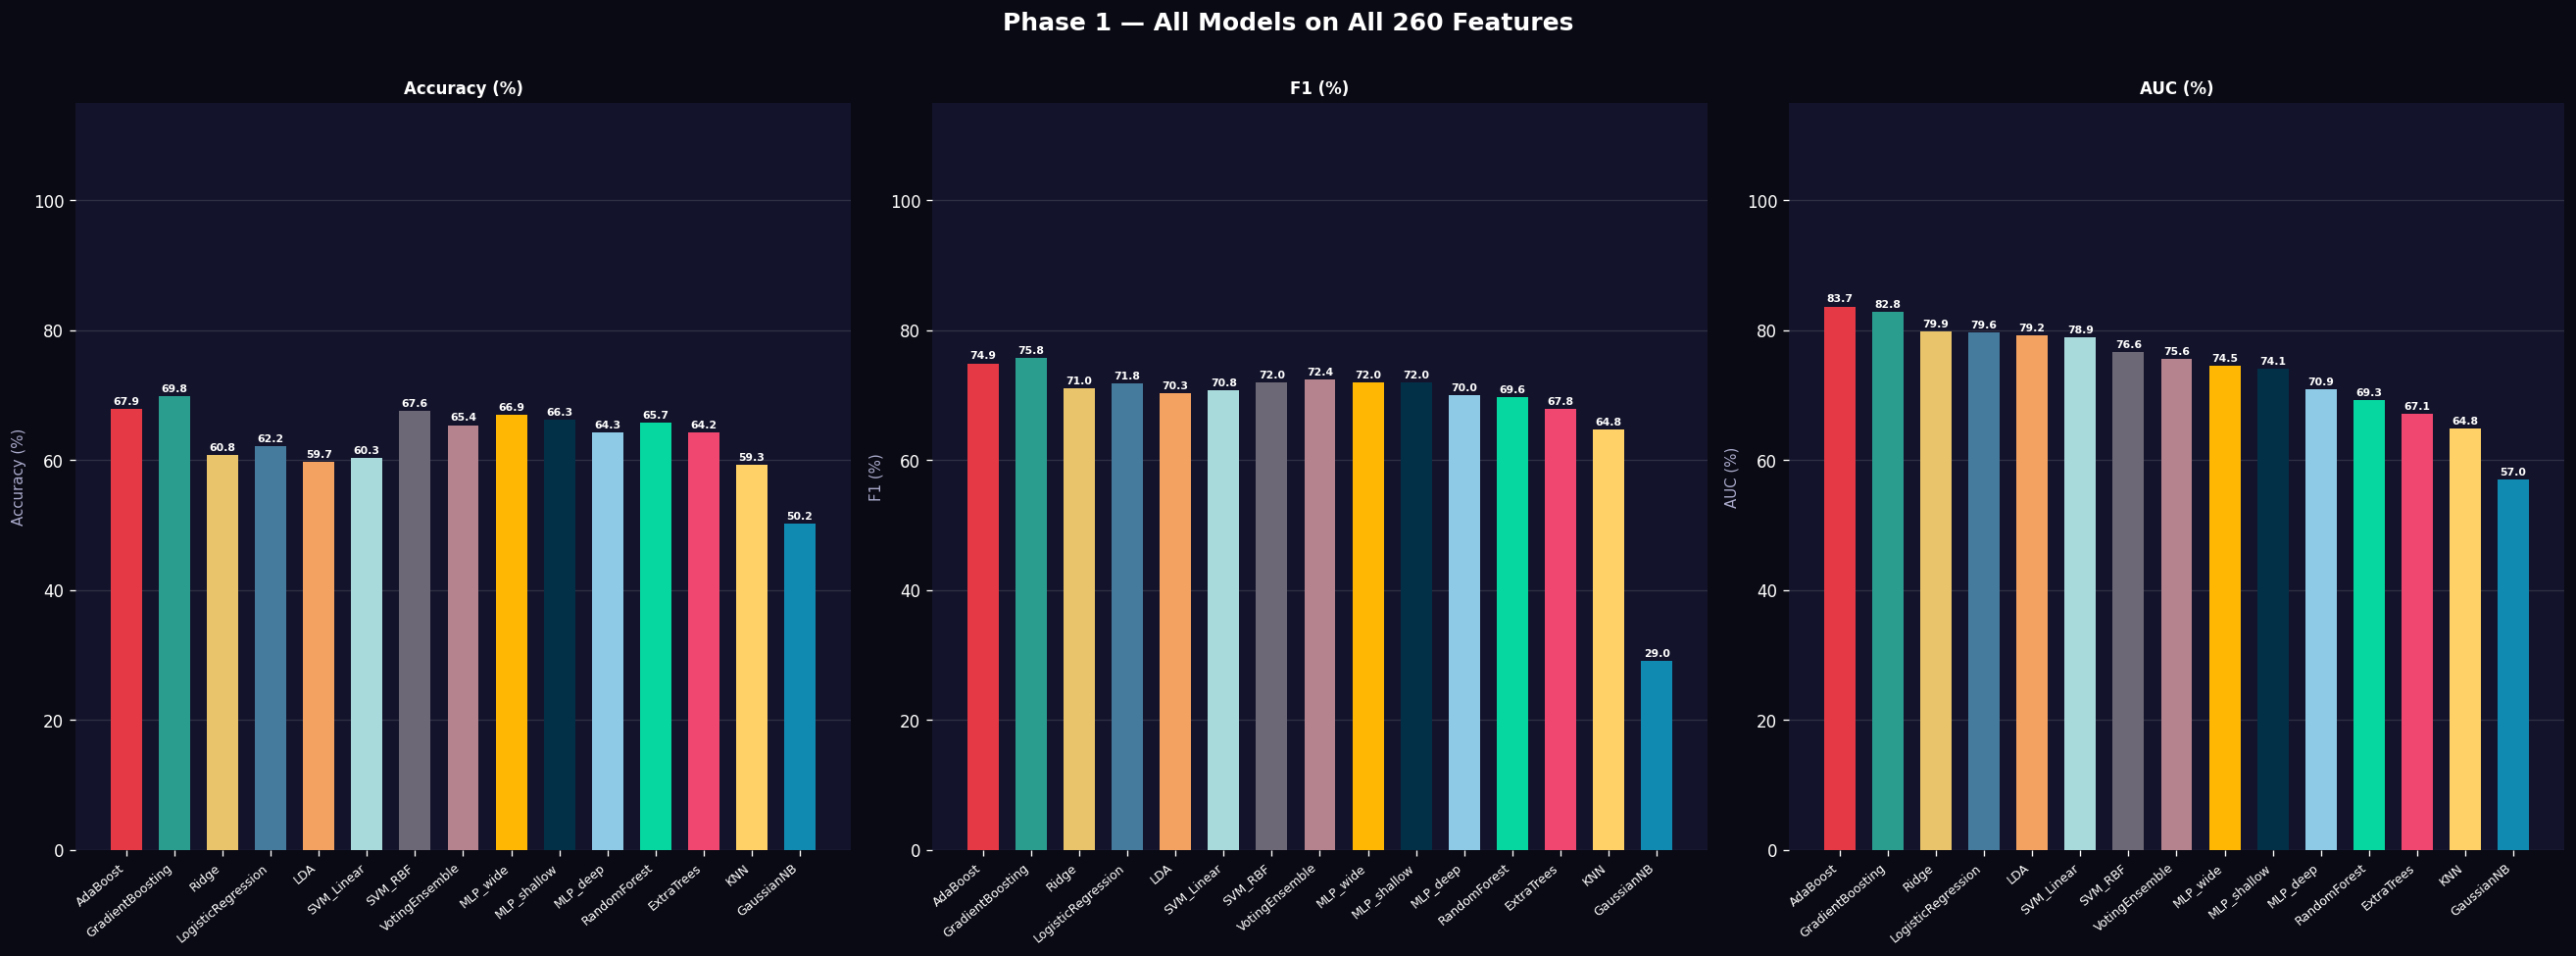

  Plot → MediaLab\plots\model_comparison_bars.png


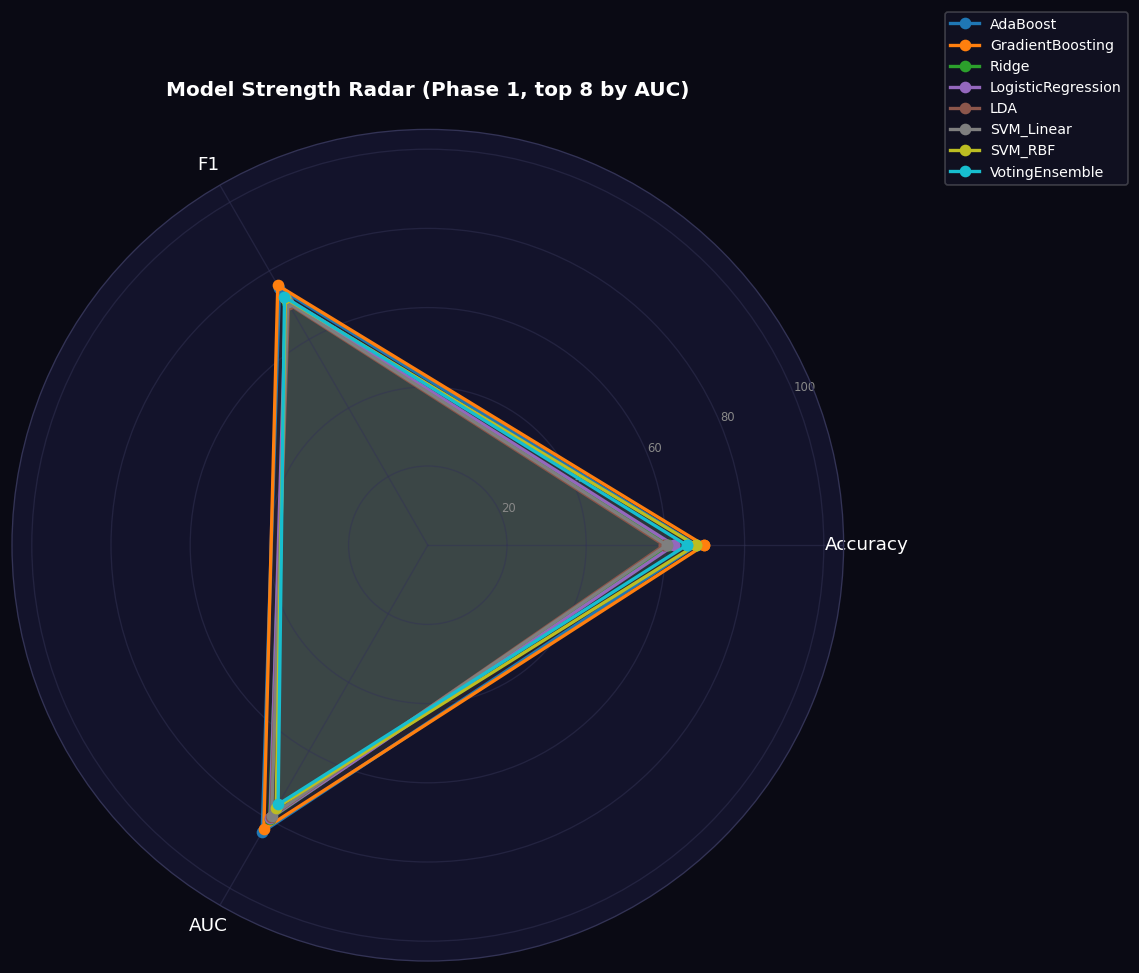

  Plot → MediaLab\plots\model_radar.png


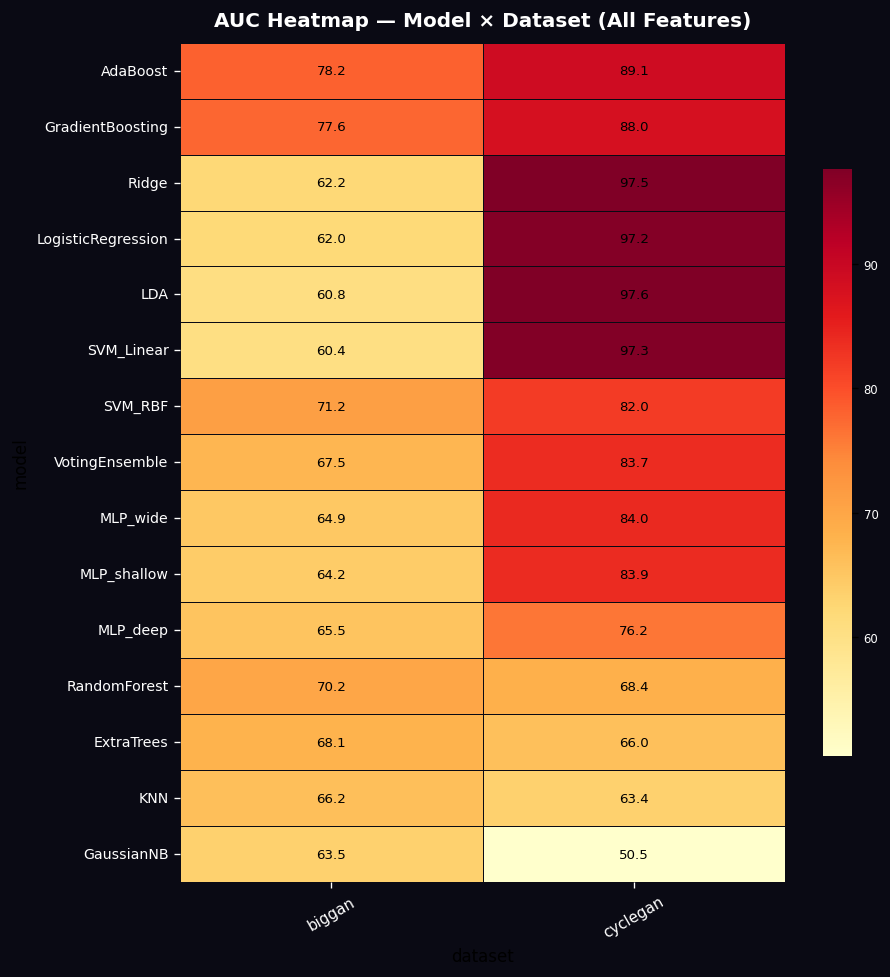

  Plot → MediaLab\plots\model_dataset_heatmap.png


In [26]:
print("[ STEP 5 ] Phase 1 summary plots …")
plot_phase1_summary(phase1_df, str(PLOTS_DIR))

---
## Cell 21 — STEP 6: Feature Selection

[ STEP 6 ] Running feature selection …

  FEATURE SELECTION — 5-method consensus
  VarianceThreshold: removed 9, kept 251
  ANOVA F-test …
  Mutual Information …
  Random Forest importance …
  L1 Logistic Regression …
  RFE (selecting top 150) …
  Scores saved → MediaLab\results/feature_scores.csv

  Top-20 consensus features:
      1. az_fft_180                           0.8164
      2. az_fft_179                           0.7338
      3. az_fft_178                           0.6759
      4. az_fft_177                           0.6538
      5. lbp_bin9                             0.6437
      6. lbp_bin2                             0.6181
      7. lbp_bin8                             0.6052
      8. az_fft_176                           0.6006
      9. az_fft_173                           0.5791
     10. lbp_bin7                             0.5618
     11. az_fft_174                           0.5561
     12. az_fft_171                           0.4673
     13. lbp_bin5                  

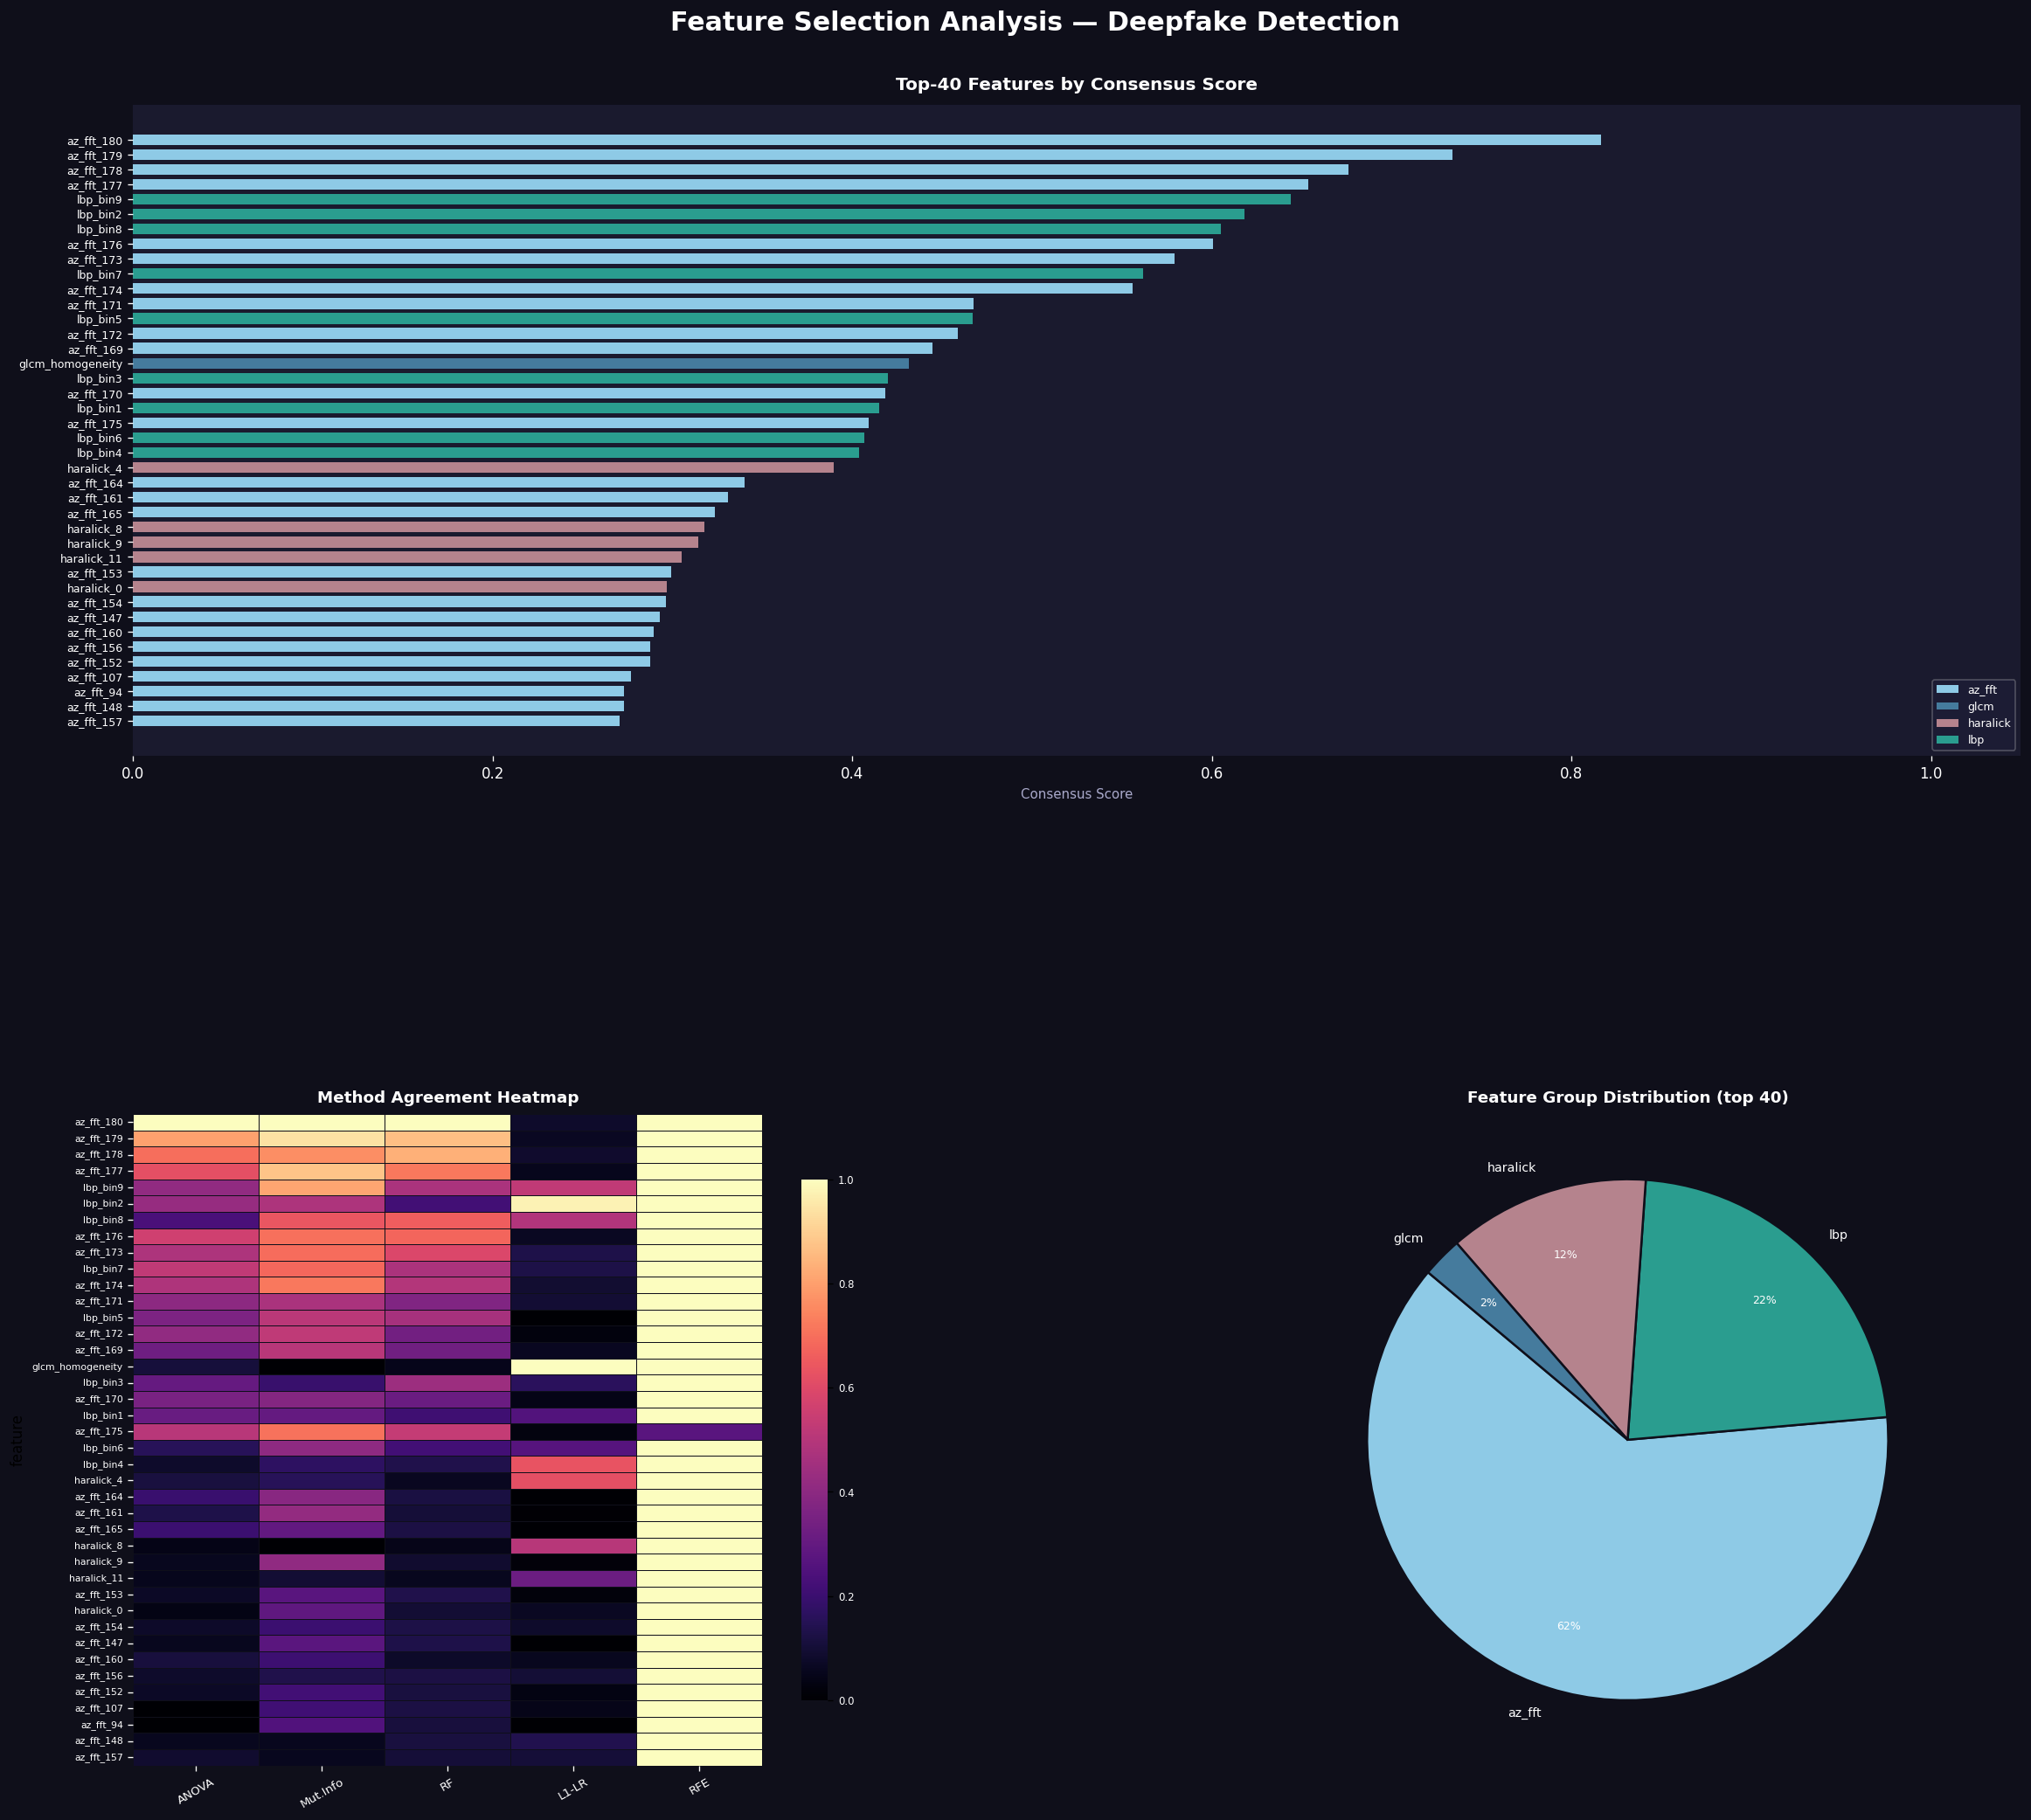

  Plot → MediaLab\plots\feature_selection_analysis.png


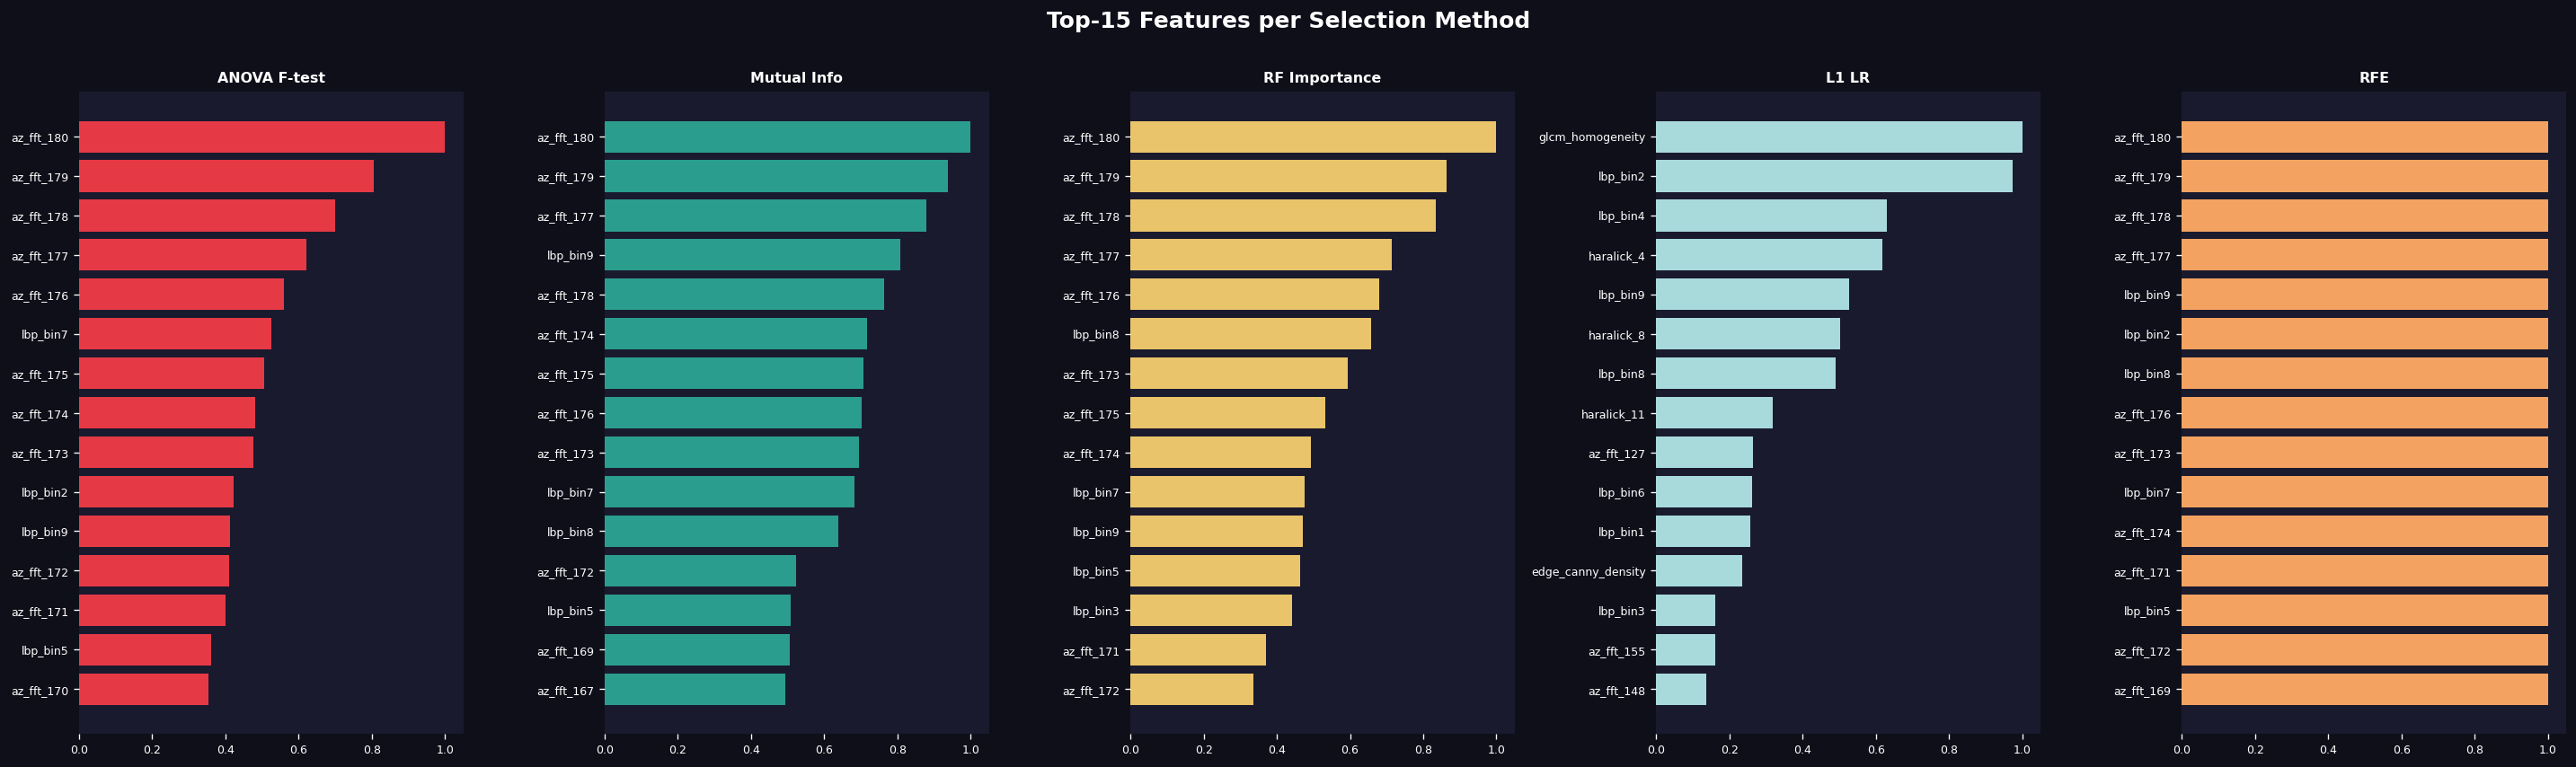

  Plot → MediaLab\plots\per_method_top_features.png


,feature,anova,mutual_info,random_forest,l1_logreg,rfe,consensus
0,az_fft_180,1.000000,1.000000,1.000000,0.081853,1.000000,0.816371
1,az_fft_179,0.804686,0.938005,0.863814,0.062719,1.000000,0.733845
2,az_fft_178,0.698926,0.764067,0.833533,0.083145,1.000000,0.675934
3,az_fft_177,0.620430,0.878762,0.715324,0.054557,1.000000,0.653815
4,lbp_bin9,0.412598,0.808794,0.470727,0.526420,1.000000,0.643708
5,lbp_bin2,0.423195,0.477695,0.216848,0.972970,1.000000,0.618142
6,lbp_bin8,0.238144,0.638306,0.658661,0.490649,1.000000,0.605152
7,az_fft_176,0.559199,0.700892,0.679485,0.063621,1.000000,0.600639
8,az_fft_173,0.477453,0.693944,0.593620,0.130320,1.000000,0.579067
9,lbp_bin7,0.525477,0.682401,0.475944,0.125118,1.000000,0.561788


In [27]:
print("[ STEP 6 ] Running feature selection …")
n_rfe_select = min(150, X_train.shape[1])
score_df, name_to_idx = run_feature_selection(
    X_train, y_train, n_rfe_select, str(RESULTS_DIR), str(PLOTS_DIR),
)

# Show top features inline
display(score_df.head(20).style.background_gradient(subset=["consensus"], cmap="YlOrRd"))

---
## Cell 22 — STEP 7: Phase 2 — Budget Sweep on Top-5 Models

[ STEP 7 ] Phase 2 budget sweep — top-5: ['AdaBoost', 'GradientBoosting', 'Ridge', 'LogisticRegression', 'LDA']

  PHASE 2 — Feature Budget Sweep (top-5 models)
  Budgets : ['20', '80', '110', '150', '200', 'ALL (260)']
  Models  : ['AdaBoost', 'GradientBoosting', 'Ridge', 'LogisticRegression', 'LDA']

  Dataset: biggan
    k = 20
      AdaBoost                Acc=68.90  F1=74.69  AUC=82.10
      GradientBoosting        Acc=69.10  F1=75.46  AUC=82.52
      Ridge                   Acc=66.10  F1=73.54  AUC=77.19
      LogisticRegression      Acc=65.40  F1=73.09  AUC=76.46
      LDA                     Acc=65.30  F1=73.08  AUC=76.89
    k = 80
      AdaBoost                Acc=63.40  F1=71.98  AUC=79.03
      GradientBoosting        Acc=63.90  F1=72.63  AUC=77.46
      Ridge                   Acc=54.00  F1=66.95  AUC=62.83
      LogisticRegression      Acc=55.00  F1=67.53  AUC=62.42
      LDA                     Acc=53.30  F1=66.62  AUC=61.66
    k = 110
      AdaBoost                Acc=

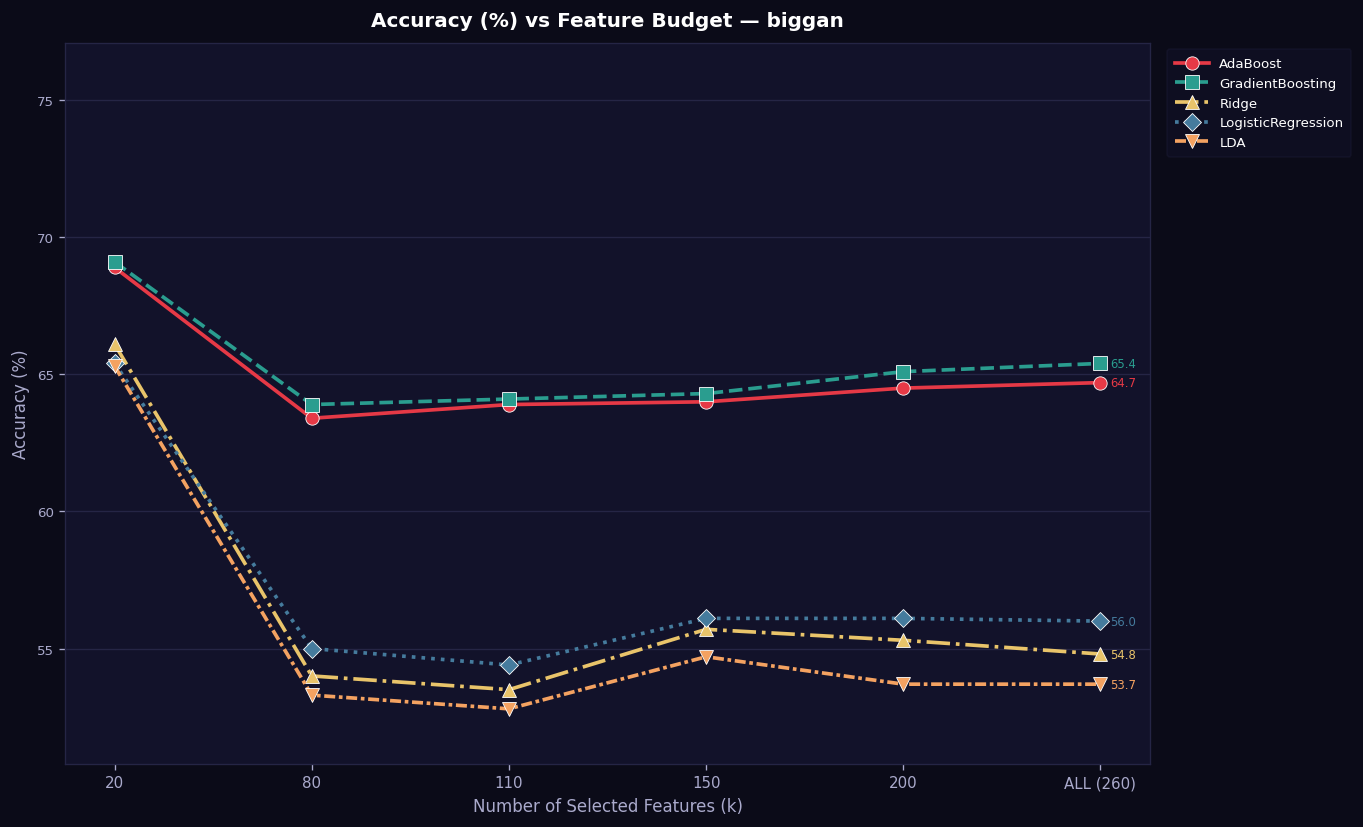

    Plot → MediaLab\plots\budget_line_acc_biggan.png


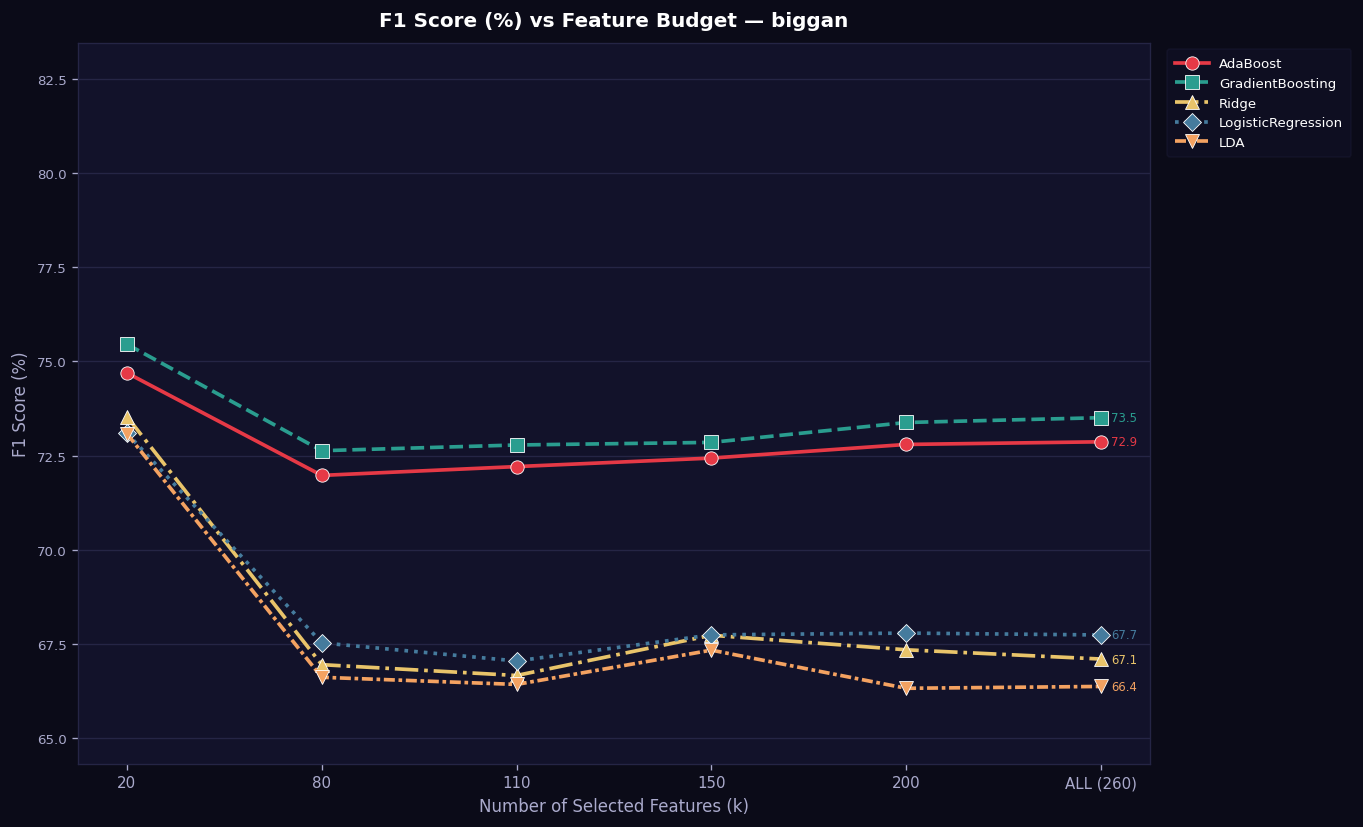

    Plot → MediaLab\plots\budget_line_f1_biggan.png


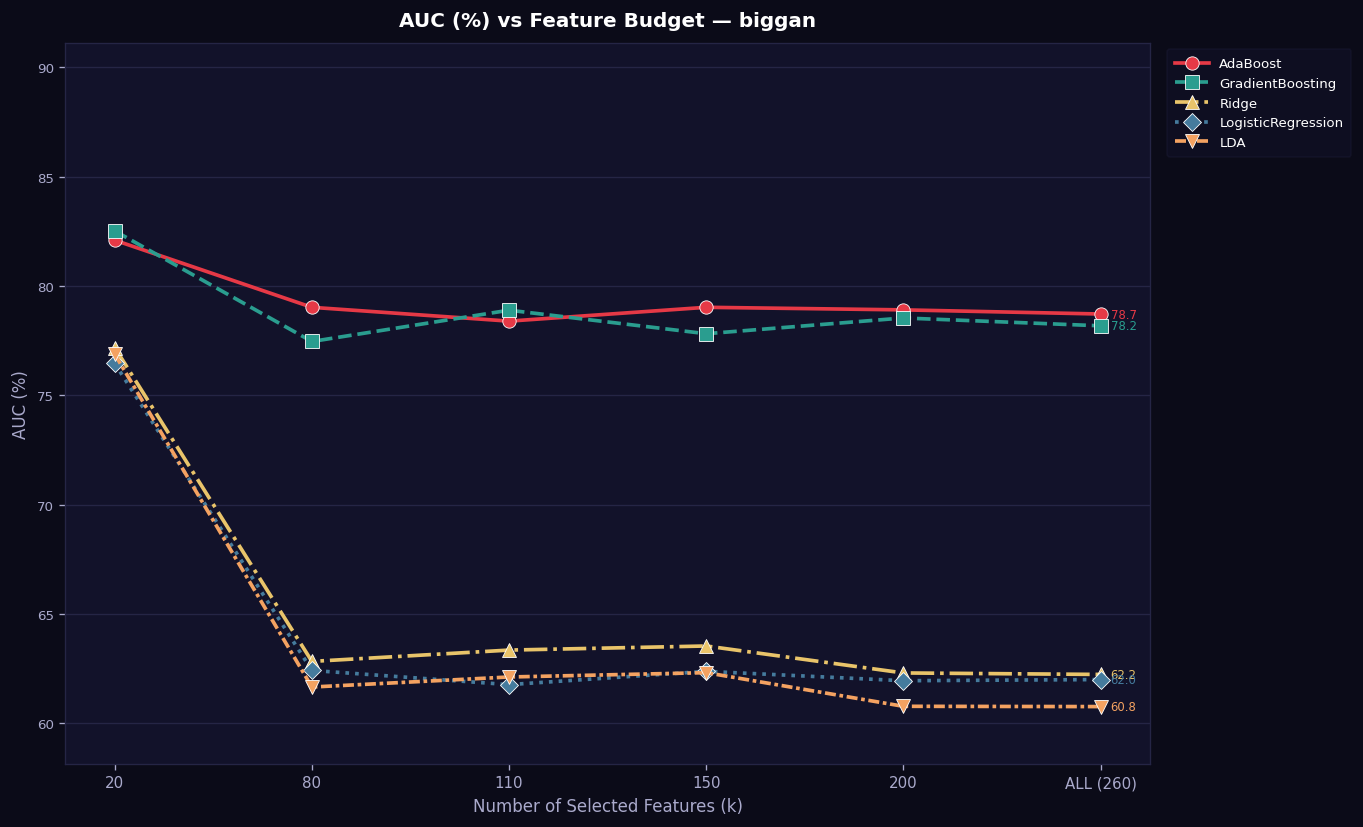

    Plot → MediaLab\plots\budget_line_auc_biggan.png


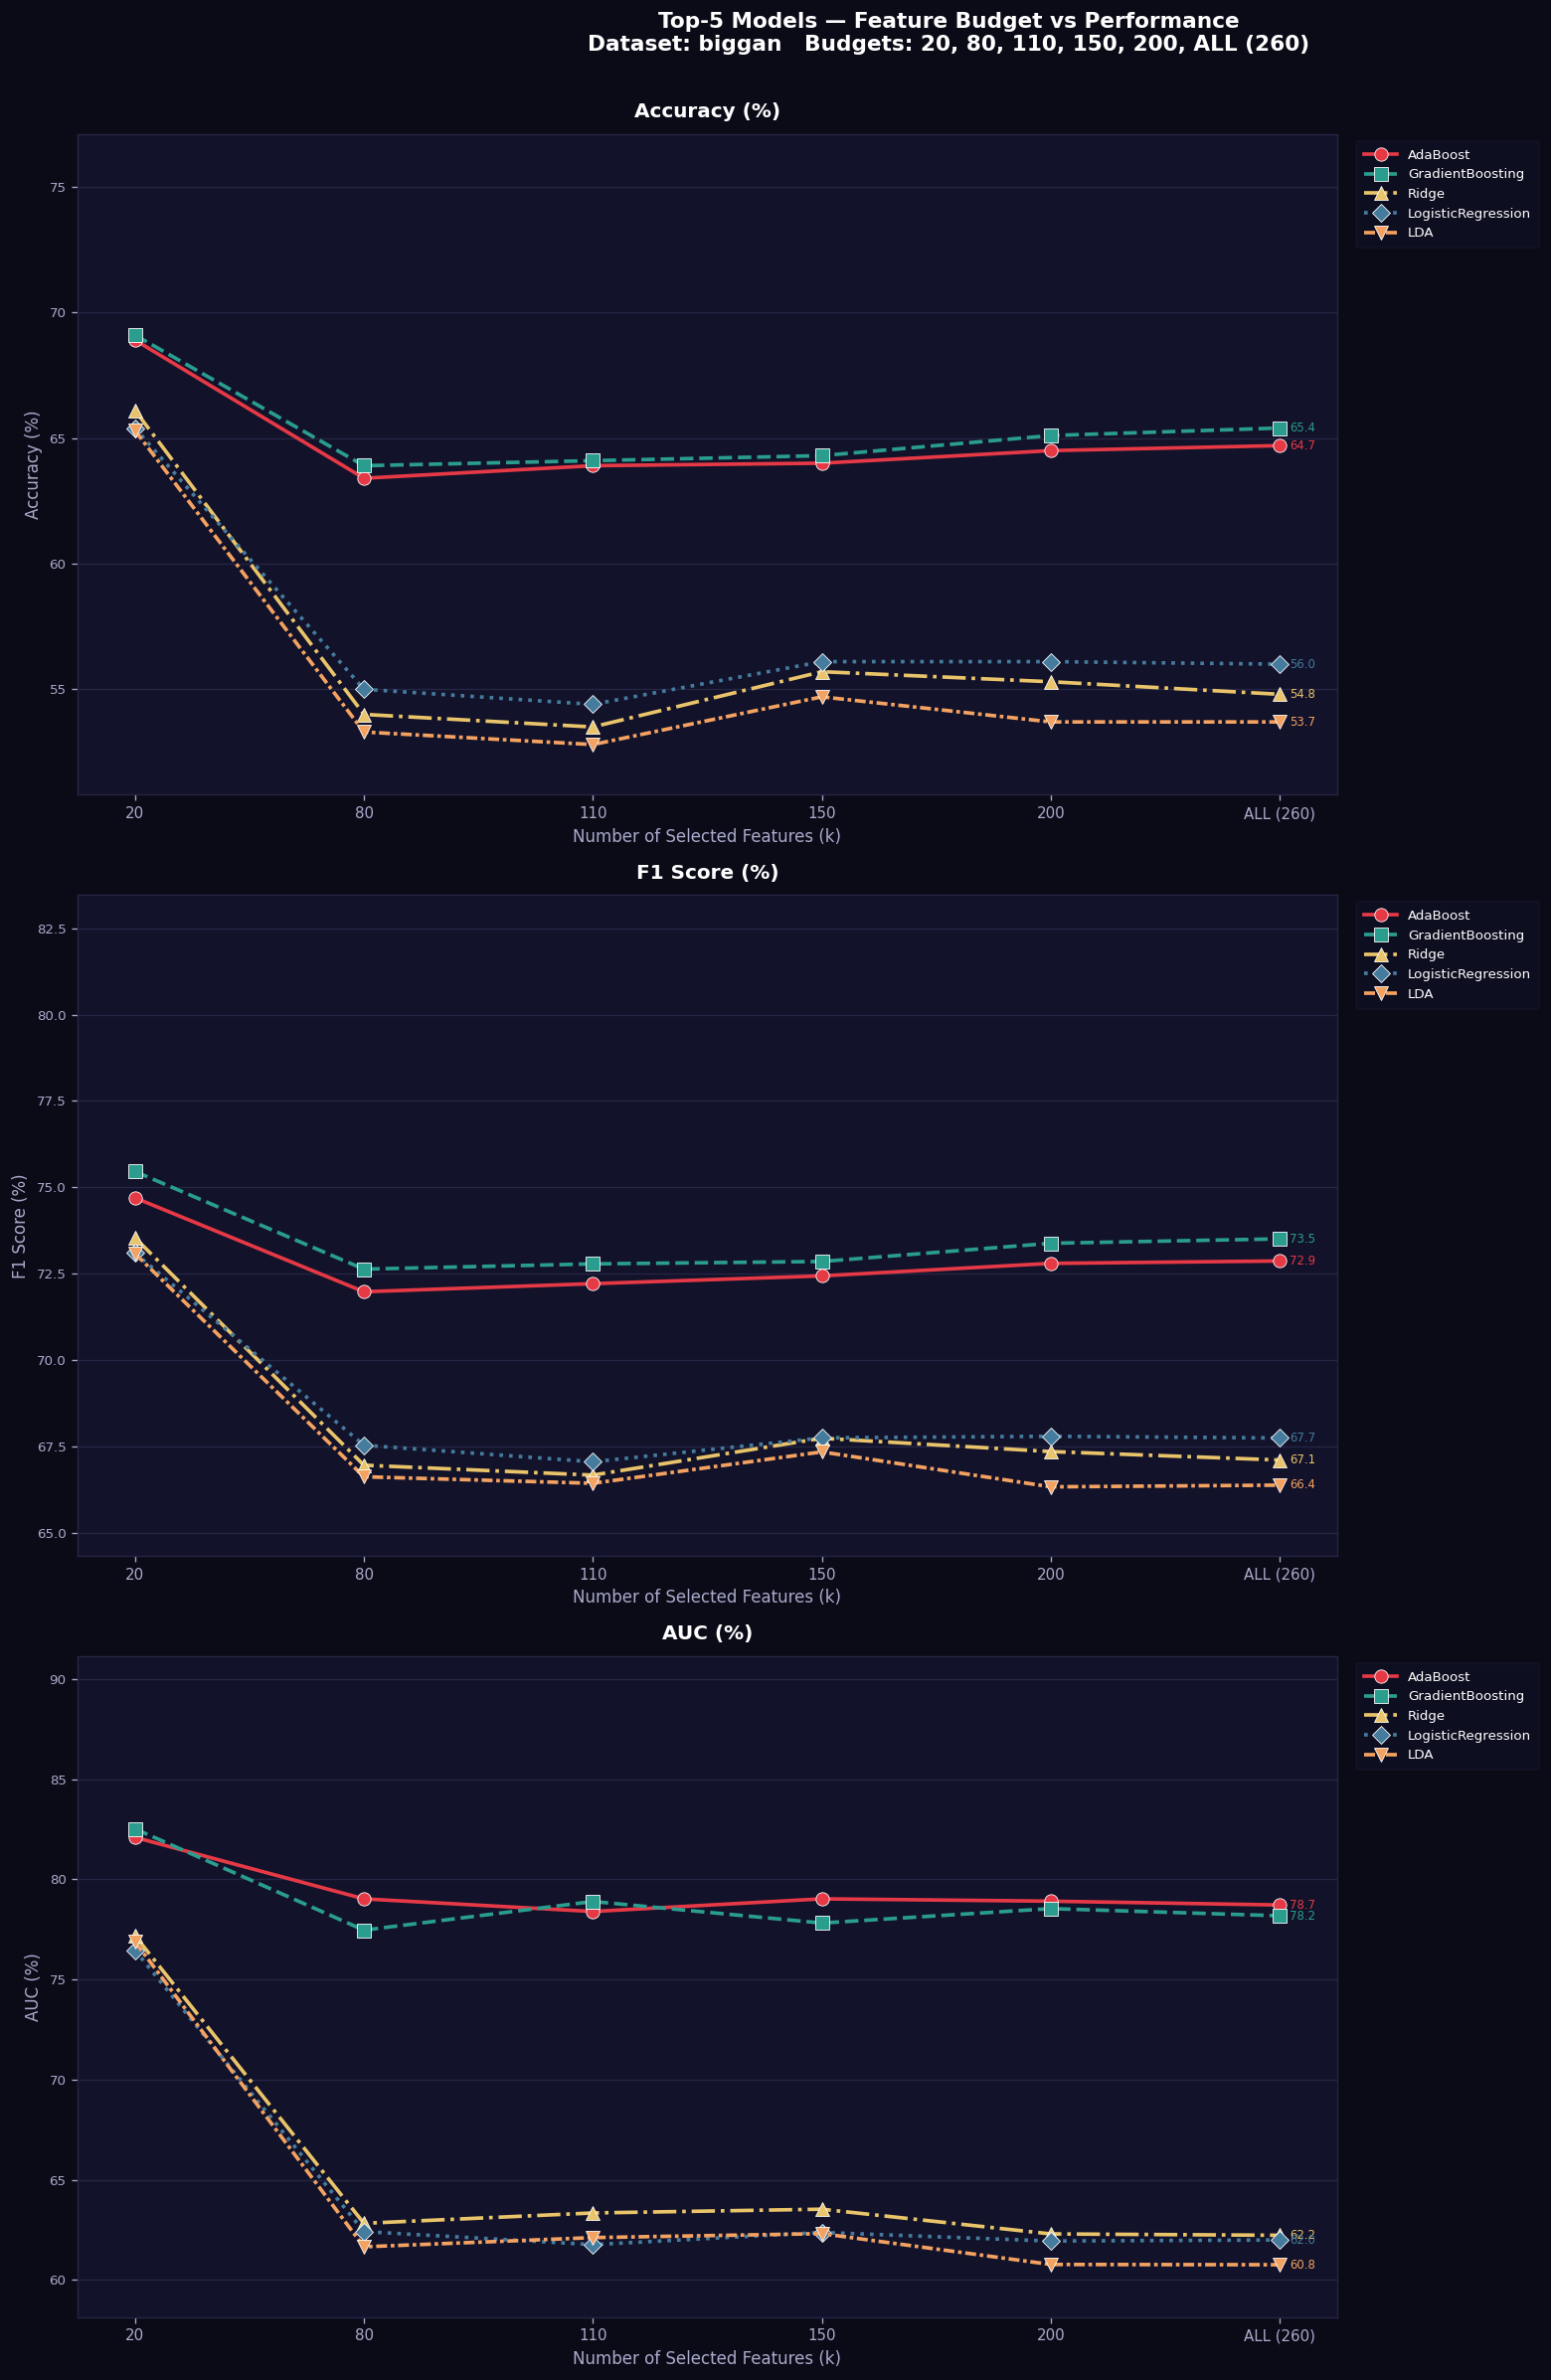

    Combined plot → MediaLab\plots\budget_combined_biggan.png

  Dataset: cyclegan
    k = 20
      AdaBoost                Acc=76.64  F1=80.45  AUC=92.31
      GradientBoosting        Acc=76.97  F1=80.46  AUC=91.53
      Ridge                   Acc=75.46  F1=79.89  AUC=93.60
      LogisticRegression      Acc=74.12  F1=79.02  AUC=92.44
      LDA                     Acc=74.62  F1=79.34  AUC=93.49
    k = 80
      AdaBoost                Acc=71.26  F1=77.11  AUC=89.23
      GradientBoosting        Acc=72.27  F1=77.05  AUC=85.49
      Ridge                   Acc=65.21  F1=74.03  AUC=96.17
      LogisticRegression      Acc=67.06  F1=75.06  AUC=95.75
      LDA                     Acc=63.19  F1=72.93  AUC=95.92
    k = 110
      AdaBoost                Acc=70.92  F1=76.78  AUC=88.71
      GradientBoosting        Acc=70.76  F1=76.10  AUC=88.81
      Ridge                   Acc=65.21  F1=74.03  AUC=96.86
      LogisticRegression      Acc=66.22  F1=74.59  AUC=96.17
      LDA                    

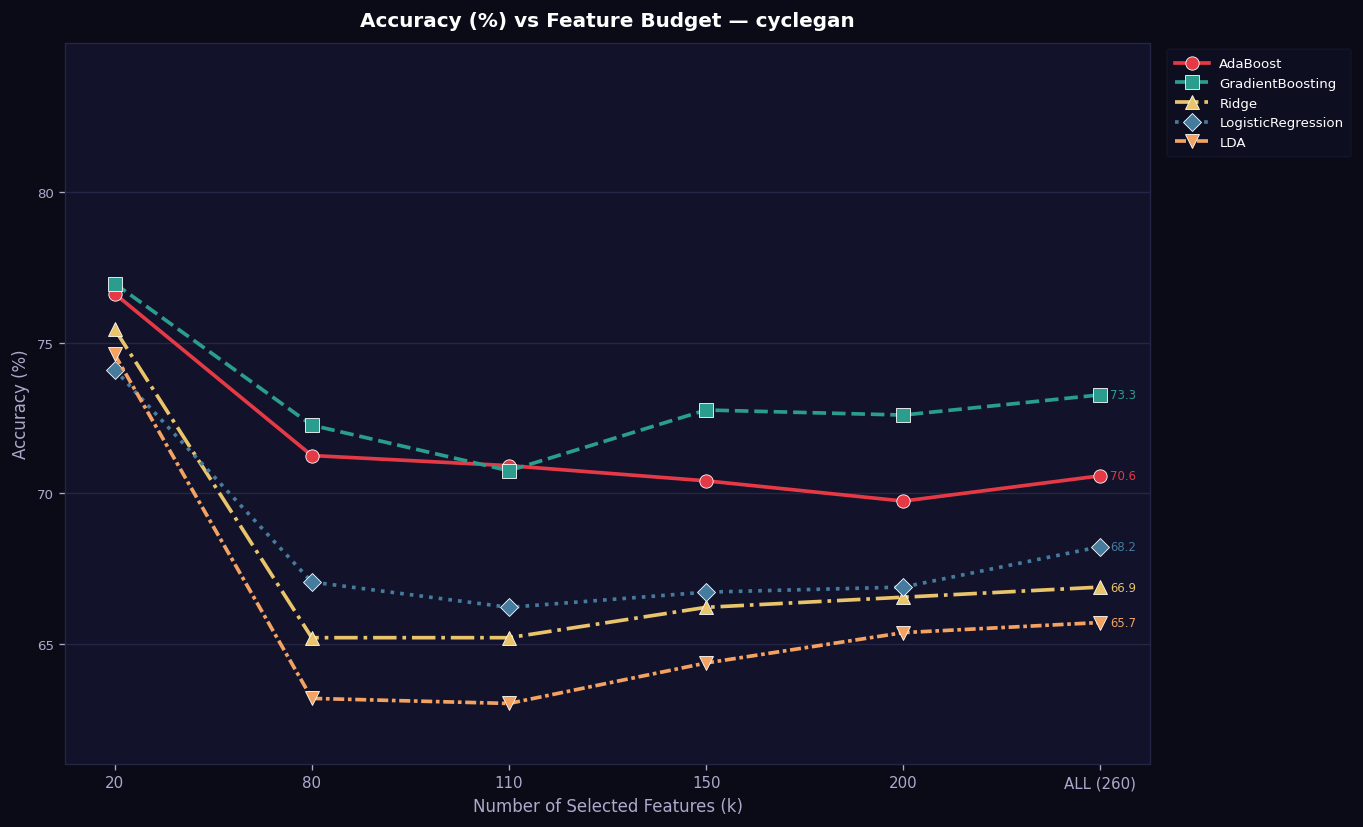

    Plot → MediaLab\plots\budget_line_acc_cyclegan.png


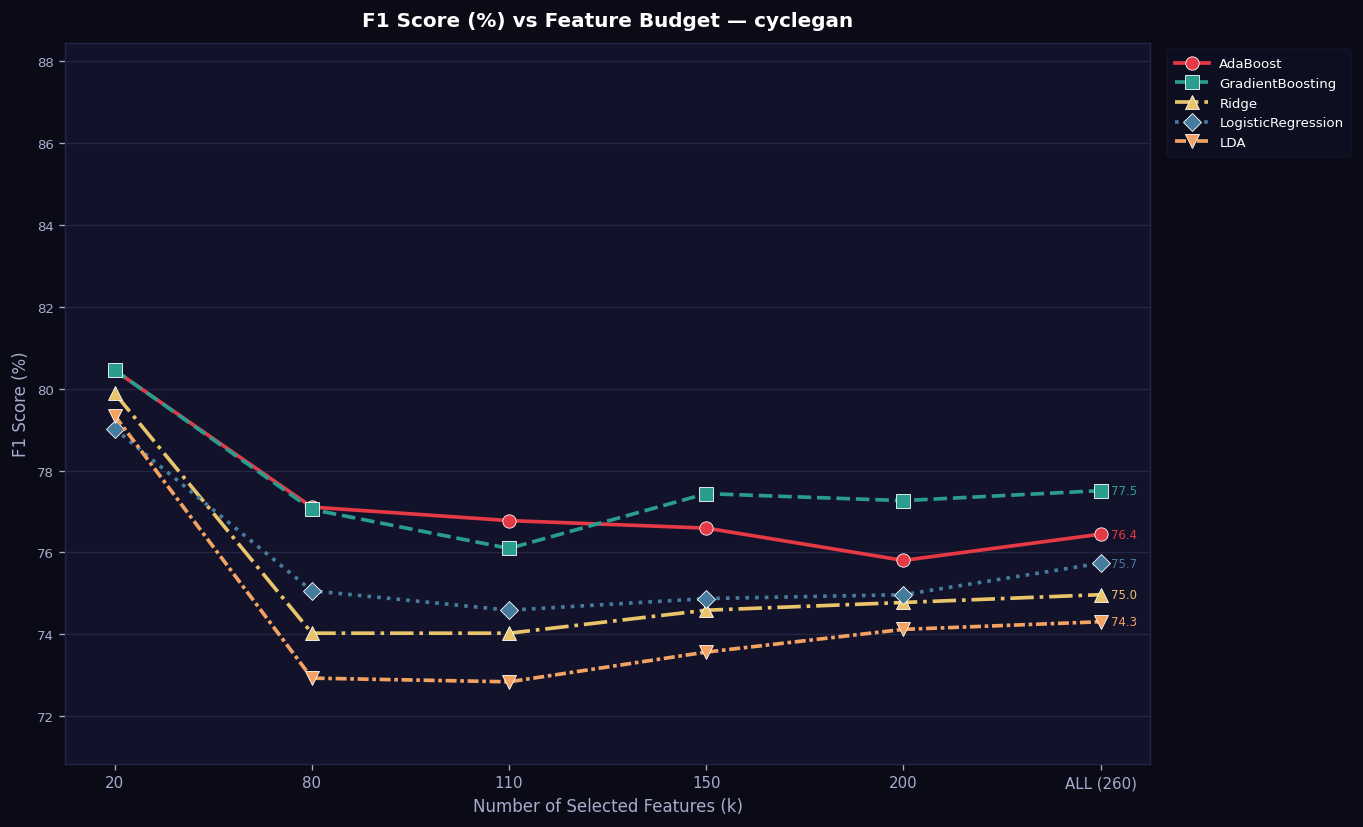

    Plot → MediaLab\plots\budget_line_f1_cyclegan.png


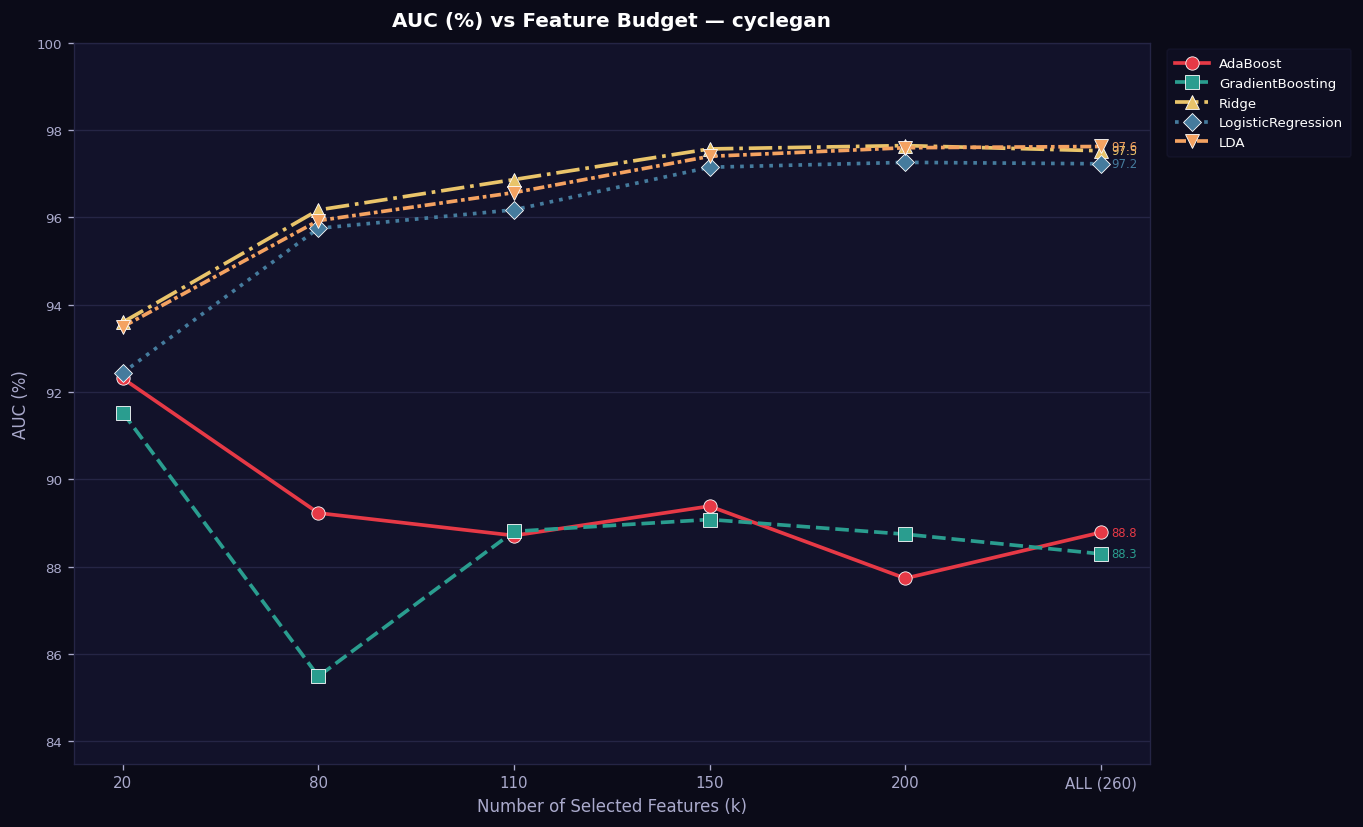

    Plot → MediaLab\plots\budget_line_auc_cyclegan.png


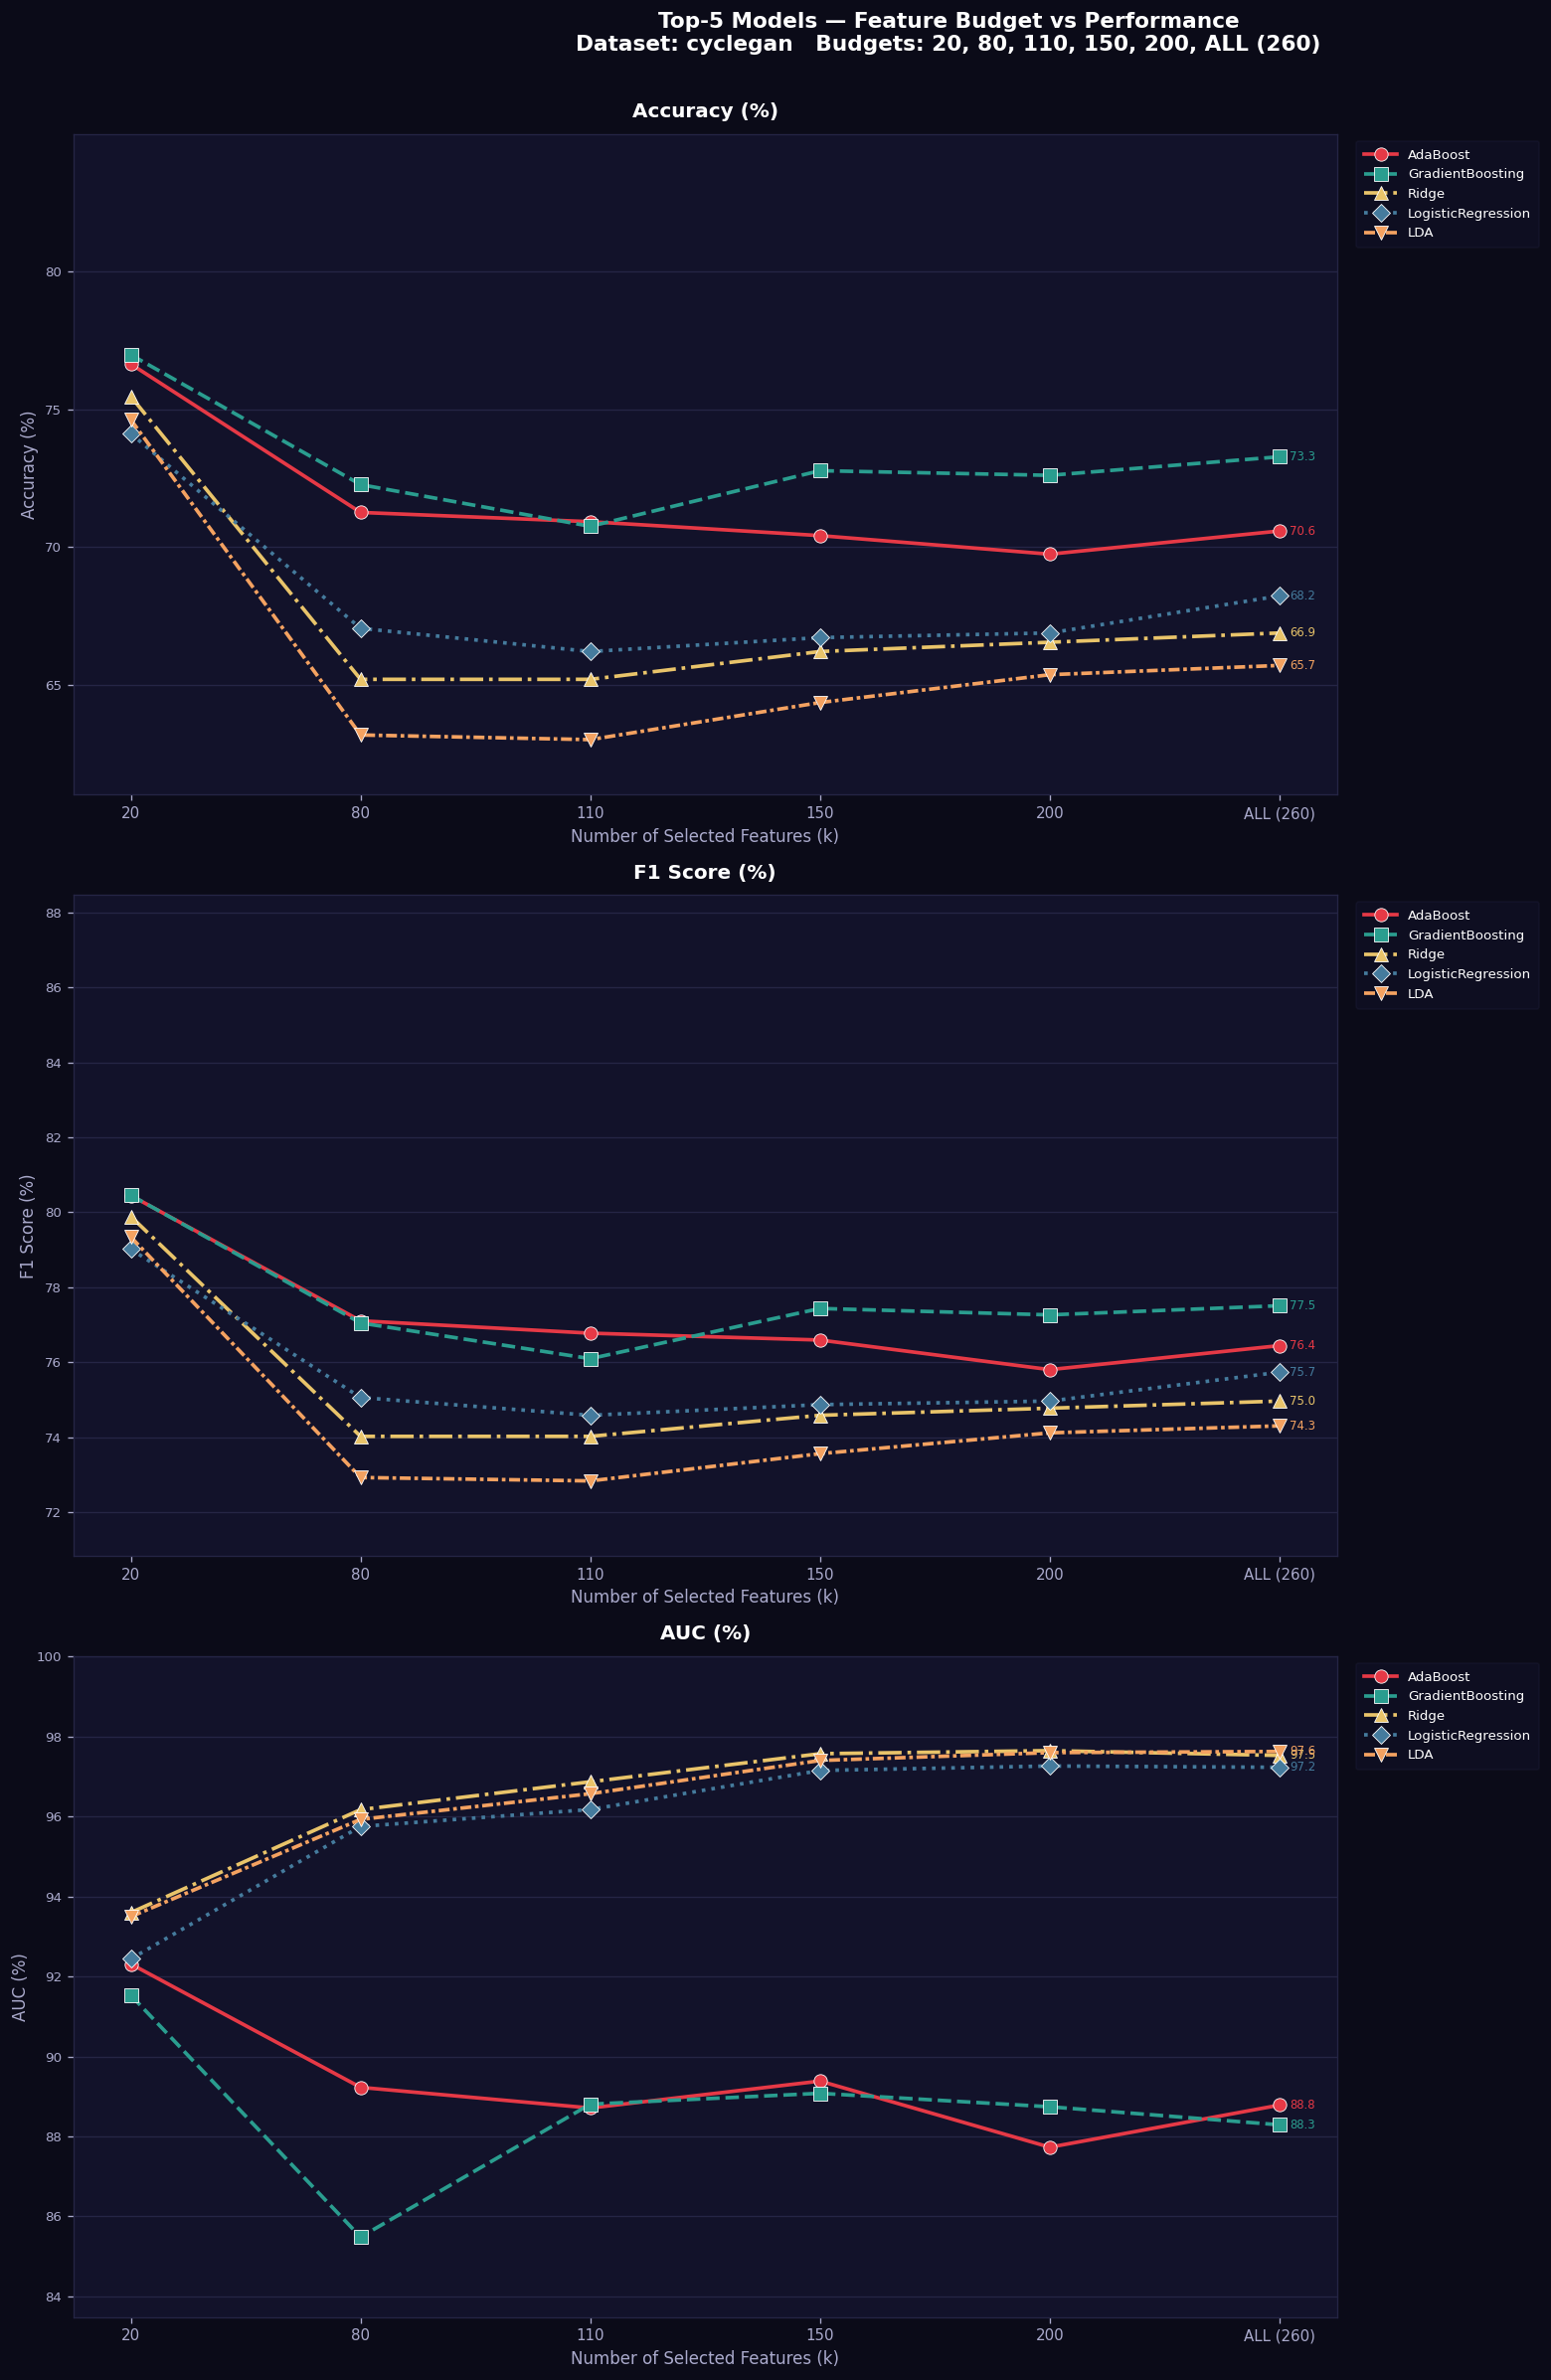

    Combined plot → MediaLab\plots\budget_combined_cyclegan.png

  Full results → MediaLab\results/results_summary.csv


In [28]:
print(f"[ STEP 7 ] Phase 2 budget sweep — top-5: {top5_names}")
budget_df = phase2_budget_sweep(
    X_train, y_train, test_data_dict,
    score_df, name_to_idx, top5_names,
    str(RESULTS_DIR), str(PLOTS_DIR),
)

---
## Cell 23 — Final Summary

In [29]:
print("\n" + "=" * 70)
print("  PHASE 2 SUMMARY  (budget sweep — mean across datasets)")
print("=" * 70)

summary = (
    budget_df.groupby(["model", "k"])[["acc", "f1", "auc"]]
    .mean().reset_index().sort_values(["model", "k"])
)
header = f"{'Model':<25} {'k':>8} {'Acc':>8} {'F1':>8} {'AUC':>8}"
print(header)
print("-" * len(header))
for _, row in summary.iterrows():
    print(f"{row['model']:<25} {int(row['k']):>8d} "
          f"{row['acc']:>8.2f} {row['f1']:>8.2f} {row['auc']:>8.2f}")
print("=" * 70)

print(f"\n[✓] All outputs saved under: {OUTPUT_DIR.resolve()}")
print("    ├── features/   — .npy feature matrices")
print("    ├── results/    — .csv tables")
print("    ├── plots/      — .png figures")
print("    └── models/     — .pkl trained pipelines")

# AUC pivot table inline
pivot = summary.pivot_table(index="model", columns="k", values="auc").round(2)
display(pivot.style.background_gradient(cmap="RdYlGn", axis=None))


  PHASE 2 SUMMARY  (budget sweep — mean across datasets)
Model                            k      Acc       F1      AUC
-------------------------------------------------------------
AdaBoost                        20    72.77    77.57    87.20
AdaBoost                        80    67.33    74.54    84.13
AdaBoost                       110    67.41    74.49    83.55
AdaBoost                       150    67.21    74.52    84.21
AdaBoost                       200    67.12    74.30    83.32
AdaBoost                       260    67.64    74.66    83.75
GradientBoosting                20    73.04    77.96    87.02
GradientBoosting                80    68.08    74.84    81.47
GradientBoosting               110    67.43    74.44    83.85
GradientBoosting               150    68.54    75.14    83.45
GradientBoosting               200    68.85    75.32    83.64
GradientBoosting               260    69.34    75.51    83.24
LDA                             20    69.96    76.21    85.19
LDA         

k,20,80,110,150,200,260
model,,,,,,
AdaBoost,87.200000,84.130000,83.550000,84.210000,83.320000,83.750000
GradientBoosting,87.020000,81.470000,83.850000,83.450000,83.640000,83.240000
LDA,85.190000,78.790000,79.340000,79.860000,79.190000,79.190000
LogisticRegression,84.450000,79.080000,78.970000,79.760000,79.600000,79.610000
Ridge,85.390000,79.500000,80.110000,80.550000,79.970000,79.880000
